## fusion

In [1]:
import pandas as pd
import os

In [ ]:
bio_add=pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/bio_sim_add.csv')
others = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/additinal_metrics_1and2percent.csv')
merged_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics.csv')

merged_df = merged_df[['disease','category']]
bio_add = bio_add[['disease','setting', 'method','cutoff_300', 'cutoff_0.01']]

len(merged_df),len(bio_add),len(others)

(1776, 2496, 2496)

In [5]:
category_map = merged_df[['disease', 'category']].drop_duplicates()

bio_add = bio_add.merge(category_map, on='disease', how='left')

In [7]:
bio_add = bio_add.merge(
    others,
    on=['disease','setting', 'method'],
    how='inner'
)

bio_add = bio_add.rename(columns={
        "cutoff_0.01": "bio_sim_150",
    "cutoff_300": "bio_sim_300"
})


In [11]:
bio_add.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics_1and2percent.csv',index=False)

In [13]:
merged_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics_1and2percent.csv')

In [16]:
# for query in['occ','models','svm_fusion','dnn_fusion']:
for query in['features']:

    if query == 'occ':
        selected_pairs = [('df_gnn_occsvm_pred', 'occ_svm'),
            ('df_gnn_occsvm_pred', 'ppi_emb_n2v'),
            ('2019_nn_all_pred', 'ppi_emb_n2v'),
            ('2019_occ_deep_svd_pred/pred.pkl', 'uniport_ppi_2019')]
        subresults = (merged_df.set_index(['setting', 'method']).loc[selected_pairs].reset_index())
    if query == 'features':
        selected_features = ['ppi_emb_df','ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb','seq_emb_esm', 'seq_emb_port']
        settings = ['df_gnn_occsvm_pred','2019_nn_all_pred','2019_rf_renamed_pred','2019_mf_add_pred',
       'graphsage', 'gcn']
        # settings = ['df_gnn_occsvm_pred']

        subresults = merged_df[(merged_df['setting'].isin(settings))&(merged_df['method'].isin(selected_features))]

    if query == 'models':
        selected_pairs = [('df_gnn_occsvm_pred','ppi_emb_n2v'),
                        ('df_gnn_occsvm_pred','Graph_sage'),
                        ('df_gnn_occsvm_pred','GCNs'),
                    ('2019_nn_all_pred','ppi_emb_n2v'),
                    ('2019_rf_renamed_pred','ppi_emb_n2v'),
                    ('2019_mf_bag_2_pred','uniport_ppi_2019')]

        subresults = (merged_df.set_index(['setting', 'method']).loc[selected_pairs].reset_index())
        method_mapping = dict(zip(selected_pairs,['svm','graph_sage','gcn','dnn','rf','mf']))
        subresults['method'] = [method_mapping[(row['setting'], row['method'])]for _, row in subresults.iterrows()]

    if query == 'svm_fusion':
        selected_features = ['early_fused', 'late_fused','mid_linear_fused','mid_geo_fused','early_fused_ppi', 'late_fused_ppi','mid_fused_ppi', 'mid_linear_fused_ppi', 'mid_geo_fused_ppi']
        # selected_features = ['early_fused_ppi', 'late_fused_ppi','mid_fused_ppi', 
        #        'mid_linear_fused_ppi', 'mid_geo_fused_ppi']
        subresults = merged_df[(merged_df['setting']=='df_gnn_occsvm_pred')&(merged_df['method'].isin(selected_features))]

    if query == 'dnn_fusion':
        selected_features = ['ppi_emb_dw','early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
            'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']

        subresults = merged_df[(merged_df['setting']=='2019_nn_all_pred')&(merged_df['method'].isin(selected_features))]

    mean_df = (
        subresults
        .groupby(['setting', 'method'], as_index=False)
        .mean(numeric_only=True)
    )
    # mean_df = mean_df[['setting', 'method',  'top_recall_300',
    #        'top_recall_10%', 'auroc', 'bedroc_1%',
    #        'bedroc_5%', 'bedroc_10', 'succ_1%', 'w_recall_1%', 'succ_5%', 'w_recall_5%',
    #        'succ_10%', 'w_recall_10%','bio_sim_100','bio_sim_300','bio_sim_1%','bio_sim_5%']].round(3)
    # # mean_df[['setting', 'method', 'top_recall_10%','w_recall_10%']]

    mean_df = mean_df[['setting', 'method', 'auroc', 
            'top_recall_150', 'top_recall_300',
            'bedroc_150', 'bedroc_300', 
            'succ_150', 'succ_300',
            'bio_sim_150','bio_sim_300']].round(3)
    mean_df.to_csv(os.path.join('/itf-fi-ml/shared/users/ziyuzh/svm/results/1and2percent_results',query+'.csv'),index=False)

In [15]:
mean_df

,setting,method,auroc,top_recall_150,top_recall_300,bedroc_150,bedroc_300,w_recall_150,w_recall_300,succ_150,succ_300,bio_sim_150,bio_sim_300
0,2019_mf_add_pred,literature_emb,0.776,0.145,0.187,0.111,0.150,0.155,0.200,0.333,0.438,0.140,0.143
1,2019_mf_add_pred,ppi_emb_df,0.750,0.145,0.221,0.089,0.139,0.156,0.235,0.354,0.479,0.119,0.110
2,2019_mf_add_pred,ppi_emb_dw,0.804,0.180,0.232,0.123,0.176,0.193,0.247,0.417,0.479,0.142,0.135
3,2019_mf_add_pred,ppi_emb_n2v,0.791,0.146,0.207,0.120,0.163,0.156,0.217,0.375,0.438,0.143,0.138
4,2019_mf_add_pred,seq_emb_esm,0.776,0.166,0.231,0.108,0.158,0.176,0.246,0.396,0.542,0.124,0.127
5,2019_mf_add_pred,seq_emb_port,0.774,0.160,0.226,0.113,0.165,0.173,0.240,0.438,0.521,0.126,0.127
6,2019_nn_all_pred,literature_emb,0.728,0.093,0.133,0.074,0.105,0.100,0.142,0.292,0.354,0.138,0.154
7,2019_nn_all_pred,ppi_emb_df,0.804,0.268,0.310,0.140,0.212,0.279,0.324,0.479,0.521,0.141,0.142
8,2019_nn_all_pred,ppi_emb_dw,0.789,0.149,0.237,0.100,0.155,0.156,0.246,0.375,0.479,0.155,0.162
9,2019_nn_all_pred,ppi_emb_n2v,0.772,0.060,0.138,0.051,0.094,0.065,0.144,0.229,0.354,0.146,0.157


In [32]:
mean_df

,setting,method,auroc,top_recall_150,top_recall_300,bedroc_150,bedroc_300,w_recall_150,w_recall_300,succ_150,succ_300,bio_sim_150,bio_sim_300
0,2019_nn_all_pred,early_fused,0.706,0.066,0.114,0.055,0.085,0.073,0.124,0.188,0.375,0.133,0.145
1,2019_nn_all_pred,early_fused_ppi,0.805,0.193,0.274,0.123,0.181,0.199,0.287,0.396,0.521,0.151,0.159
2,2019_nn_all_pred,late_fused,0.769,0.153,0.222,0.095,0.145,0.162,0.229,0.354,0.458,0.144,0.153
3,2019_nn_all_pred,late_fused_ppi,0.668,0.102,0.144,0.069,0.104,0.106,0.153,0.292,0.375,0.129,0.144
4,2019_nn_all_pred,mid_fused,0.802,0.231,0.300,0.157,0.217,0.243,0.312,0.500,0.562,0.131,0.126
5,2019_nn_all_pred,mid_fused_ppi,0.803,0.192,0.283,0.150,0.209,0.203,0.295,0.417,0.562,0.130,0.128
6,2019_nn_all_pred,ppi_emb_dw,0.789,0.149,0.237,0.100,0.155,0.156,0.246,0.375,0.479,0.155,0.162


In [ ]:
# selected_features = ['ppi_emb_df','ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb','seq_emb_esm', 'seq_emb_port']
# # settings = ['df_gnn_occsvm_pred','2019_nn_all_pred','2019_rf_renamed_pred']
# settings = ['df_gnn_occsvm_pred']

# subresults = merged_df[(merged_df['setting'].isin(settings))&(merged_df['method'].isin(selected_features))]

Index(['method', 'top_recall_25', 'top_recall_300', 'top_recall_10%',
       'top_recall_30%', 'auroc', 'rank_ratio', 'bedroc_1%', 'bedroc_5%',
       'bedroc_10', 'bedroc_30', 'weights_1', 'weights_2', 'weights_3',
       'disease', 'category', 'setting', 'succ_1%', 'w_recall_1%', 'succ_5%',
       'w_recall_5%', 'succ_10%', 'w_recall_10%', 'succ_30%', 'w_recall_30%',
       'feature_x', 'cutoff_0.0%', 'bio_sim_5%', 'bio_sim_10%', 'cutoff_0.17%',
       'cutoff_0.22%', 'cutoff_0.28%', 'cutoff_0.33%', 'cutoff_0.39%',
       'cutoff_0.44%', 'cutoff_0.5%', 'feature_y', 'bio_sim_100',
       'bio_sim_200', 'bio_sim_300', 'bio_sim_1%'],
      dtype='object')

In [84]:
subresults.sort_values(by='auroc', ascending=False)

,method,top_recall_25,top_recall_300,top_recall_10%,top_recall_30%,auroc,rank_ratio,bedroc_1%,bedroc_5%,bedroc_10,...,cutoff_0.28%,cutoff_0.33%,cutoff_0.39%,cutoff_0.44%,cutoff_0.5%,feature_y,bio_sim_100,bio_sim_200,bio_sim_300,bio_sim_1%
1242,late_f...,1.0,1.0,1.0,1.00,1.000,0.000,0.931,0.986,0.993,...,0.044036,0.042562,0.044232,0.043572,0.045604,late_f...,0.135464,0.102703,0.092019,0.112245
1628,mid_li...,1.0,1.0,1.0,1.00,1.000,0.000,0.980,0.996,0.998,...,0.124721,0.122605,0.118029,0.114798,0.114480,mid_li...,0.299270,0.279368,0.263113,0.283019
1630,mid_ge...,1.0,1.0,1.0,1.00,0.999,0.001,0.806,0.958,0.979,...,0.121974,0.116895,0.114673,0.115136,0.114558,mid_ge...,0.300126,0.308190,0.286648,0.308970
1634,late_f...,1.0,1.0,1.0,1.00,0.999,0.001,0.912,0.982,0.991,...,0.000000,0.000000,0.000000,0.000000,0.120791,late_f...,0.278626,0.295529,0.287736,0.281576
1238,mid_ge...,1.0,1.0,1.0,1.00,0.999,0.001,0.866,0.972,0.986,...,0.032520,0.032740,0.032915,0.033196,0.034706,mid_ge...,0.120516,0.099228,0.090498,0.106650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754,mid_li...,0.0,0.0,0.0,0.00,0.385,0.615,0.000,0.000,0.000,...,0.097995,0.097474,0.096160,0.100203,0.097308,mid_li...,0.218717,0.207137,0.180995,0.204411
1394,early_...,0.0,0.0,0.0,0.25,0.380,0.620,0.000,0.000,0.006,...,0.003333,0.002603,0.002506,0.002020,0.001962,early_...,0.012931,0.015291,0.011211,0.010638
1756,mid_ge...,0.0,0.0,0.0,0.00,0.378,0.622,0.000,0.000,0.000,...,0.095020,0.092386,0.090085,0.092351,0.095128,mid_ge...,0.260700,0.217028,0.185742,0.222013
1758,early_...,0.0,0.0,0.0,0.00,0.349,0.651,0.000,0.000,0.000,...,0.118239,0.114975,0.115609,0.113704,0.113371,early_...,0.229081,0.234763,0.232673,0.249119


In [79]:
mean_df[['setting', 'method', 
       'top_recall_10%', 'w_recall_10%']].sort_values(by='top_recall_10%', ascending=False)

,setting,method,top_recall_10%,w_recall_10%
2,df_gnn...,mid_ge...,0.554,0.568
1,df_gnn...,late_f...,0.530,0.550
3,df_gnn...,mid_li...,0.497,0.512
0,df_gnn...,early_...,0.442,0.459


In [ ]:
selected_features = ['ppi_emb_dw','early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
       'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']

subresults = merged_df[(merged_df['setting']=='2019_nn_all_pred')&(merged_df['method'].isin(selected_features))]
mean_df = (
    subresults
    .groupby(['setting', 'method'], as_index=False)
    .mean(numeric_only=True)
)
mean_df = mean_df[['setting', 'method',  'top_recall_300',
       'top_recall_10%', 'auroc', 'bedroc_1%',
       'bedroc_5%', 'bedroc_10', 'succ_1%', 'w_recall_1%', 'succ_5%', 'w_recall_5%',
       'succ_10%', 'w_recall_10%','bio_sim_100','bio_sim_300']].round(3)

In [31]:
a = subresults[['method','disease','top_recall_25', 'top_recall_300', 'top_recall_10%',
       'top_recall_30%', 'auroc', 'rank_ratio', 'bedroc_1%', 'bedroc_5%']]
file1 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_df_oob.xlsx'
b = pd.read_excel(file1, sheet_name='disease')

In [ ]:
b['method'] = b['para']
b = b[['method','disease','top_recall_25', 'top_recall_300', 'top_recall_10%',
       'top_recall_30%', 'auroc', 'rank_ratio', 'bedroc_1', 'bedroc_5']]

In [40]:
b = b[b['method'].isin(['early_fused','later_feature_fused_avg', 'linear_fused','geo_fused'])]
b['method'] = b['method'].replace({
    'linear_fused':'mid_linear_fused',
    'geo_fused':'mid_geo_fused',
    'later_feature_fused_avg':'late_fused'
})

In [22]:
selected_features = ['ppi_emb_df','ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb','seq_emb_esm', 'seq_emb_port']
settings = ['df_gnn_occsvm_pred','2019_nn_all_pred','2019_rf_renamed_pred']
subresults = merged_df[(merged_df['setting'].isin(settings))&(merged_df['method'].isin(selected_features))]


In [23]:
subresults['setting'] = subresults['setting'].replace({
    'df_gnn_occsvm_pred':'SVMs',
    '2019_nn_all_pred':'DNNs',
    '2019_rf_renamed_pred':'RFs'
})

/tmp/ipykernel_1850658/2481392718.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults['setting'] = subresults['setting'].replace({


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import to_rgb

def plot_metric_boxplot_old(filter_df, dis, legend_order, metrics_order):
    df = filter_df.copy()

    # ---- Explicit method order ----
    df["method"] = pd.Categorical(
        df["method"],
        categories=legend_order,
        ordered=True
    )

    # ---- Explicit metric order ----
    df["metric"] = pd.Categorical(
        df["metric"],
        categories=metrics_order,
        ordered=True
    )

    metrics = [m for m in metrics_order if m in df["metric"].unique()]
    n = len(metrics)

    # ---- ONE ROW layout, taller figure ----
    fig, axes = plt.subplots(
        nrows=1,
        ncols=n,
        figsize=(4.5 * n, 6),   # <- wider and higher
        sharey=False            # each metric has its own y-scale
    )

    # Ensure axes iterable if only 1 metric
    if n == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        sub = df[df["metric"] == metric]

        sns.boxplot(
            data=sub,
            x="method",
            y="value",
            hue="method",               # seaborn ≥0.14 compatible
            order=legend_order,
            hue_order=legend_order,
            palette="Set2",
            dodge=False,
            legend=False,
            ax=ax
        )

        ax.set_title(metric, fontsize=12)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=35)
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle(f"{dis.upper()} Comparison Across Metrics", fontsize=14, y=1.05)
    fig.supxlabel("Method", fontsize=12)
    fig.supylabel("Value", fontsize=12)

    plt.tight_layout()
    plt.show()


def _lighten_color(color, amount=0.55):
    """
    Lighten a matplotlib color (hex string or RGB tuple) by blending with white.
    amount in [0,1]; higher = lighter.
    """
    r, g, b = to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

def plot_metric_boxplot(
    df_long, dis, legend_order_svm,
    df_long2, legend_order_dnn,
    metrics_order,
    prefix1="SVM", prefix2="DNN",
    group_gap_label="__GAP__",     # unique token for a visible gap row
    lighten_amount_dnn=0.50        # increased so DNN colors are lighter
):
    df1 = df_long.copy()
    df2 = df_long2.copy()

    # --- metric order ---
    df1["metric"] = pd.Categorical(df1["metric"], categories=metrics_order, ordered=True)
    df2["metric"] = pd.Categorical(df2["metric"], categories=metrics_order, ordered=True)
    metrics = [m for m in metrics_order if (m in df1["metric"].unique() or m in df2["metric"].unique())]
    n = len(metrics)

    # --- base method names ---
    df1["method_base"] = df1["method"].astype(str)
    df2["method_base"] = df2["method"].astype(str)

    # --- legend/y labels (renamed with prefix) ---
    df1["legend_label"] = prefix1 + " " + df1["method_base"]
    df2["legend_label"] = prefix2 + " " + df2["method_base"]
    df1["method_disp"] = df1["legend_label"]
    df2["method_disp"] = df2["legend_label"]

    # --- y-axis order: SVM group + GAP + DNN group ---
    gap_size = 2
    gap_labels = [f"{group_gap_label}_{i}" for i in range(gap_size)]

    y_order = (
        [f"{prefix1} {m}" for m in legend_order_svm] +
        gap_labels +
        [f"{prefix2} {m}" for m in legend_order_dnn]
    )

    # ---------- COLOR RULES ----------
    # made lighter colors even lighter
    BLUE   = "#386cb0"
    PINK   = "#fbb4d9"   # lighter pink
    ORANGE = "#fed9a6"   # lighter orange
    GREEN  = "#d9f0c2"   # lighter green
    GREEN2 = "#66bd63"

    def base_color_for_method(m: str, mid_toggle: int):
        ml = m.lower()

        if "early" in ml:
            return ORANGE
        if "late" in ml:
            return BLUE
        if "mid" in ml:
            return GREEN2 if (mid_toggle % 2 == 0) else GREEN
        elif "ppi" in ml:
            return PINK
        return "#808080"

    # unique base methods across both orders
    all_base = []
    for m in legend_order_svm + legend_order_dnn:
        if m not in all_base:
            all_base.append(m)

    # assign colors per base method
    mid_idx = 0
    base_method_color = {}
    for m in all_base:
        base_method_color[m] = base_color_for_method(m, mid_idx)
        if "mid" in m.lower():
            mid_idx += 1

    # palettes for prefixed labels: SVM = base, DNN = lighter base
    legend_order_labels = [f"{prefix1} {m}" for m in legend_order_svm] + [f"{prefix2} {m}" for m in legend_order_dnn]
    palette = {}
    for m in legend_order_svm:
        palette[f"{prefix1} {m}"] = base_method_color[m]
    for m in legend_order_dnn:
        palette[f"{prefix2} {m}"] = _lighten_color(base_method_color[m], amount=lighten_amount_dnn)

    # --- figure ---
    fig, axes = plt.subplots(
        nrows=1,
        ncols=n,
        figsize=(4.5 * n, 4.8),
        sharey=True
    )
    if n == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        sub1 = df1[df1["metric"] == metric]
        sub2 = df2[df2["metric"] == metric]

        dummy = pd.DataFrame({
            "method_disp": [group_gap_label],
            "value": [0.0],
            "legend_label": [legend_order_labels[0]]
        })

        if not sub1.empty:
            sns.boxplot(
                data=pd.concat([sub1[["method_disp", "value", "legend_label"]], dummy], ignore_index=True),
                y="method_disp",
                x="value",
                order=y_order,
                hue="legend_label",
                hue_order=legend_order_labels,
                palette=palette,
                dodge=False,
                legend=False,
                showfliers=False,
                ax=ax
            )

        if not sub2.empty:
            sns.boxplot(
                data=pd.concat([sub2[["method_disp", "value", "legend_label"]], dummy], ignore_index=True),
                y="method_disp",
                x="value",
                order=y_order,
                hue="legend_label",
                hue_order=legend_order_labels,
                palette=palette,
                dodge=False,
                legend=False,
                showfliers=False,
                ax=ax
            )

        # bigger subplot title
        ax.set_title(metric, fontsize=16)

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(axis="x", alpha=0.25)

        # bigger x tick labels
        ax.tick_params(axis="x", labelsize=13)

        # y labels only on first subplot
        if i != 0:
            ax.set_yticklabels([])
            ax.tick_params(axis="y", length=0)
        else:
            labels = [t.get_text() for t in ax.get_yticklabels()]
            cleaned = []
            for lab in labels:
                if group_gap_label in lab:
                    cleaned.append("")
                else:
                    cleaned.append(lab)
            ax.set_yticklabels(cleaned, fontsize=13)

    plt.subplots_adjust(wspace=0)

    # legend with prefixed labels
    svm_labels = [f"{prefix1} {m}" for m in legend_order_svm]
    dnn_labels = [f"{prefix2} {m}" for m in legend_order_dnn]

    svm_handles = [Patch(facecolor=palette[lbl], label=lbl) for lbl in svm_labels]
    dnn_handles = [Patch(facecolor=palette[lbl], label=lbl) for lbl in dnn_labels]

    ncol = max(len(svm_handles), len(dnn_handles))
    blank = Patch(facecolor=(0, 0, 0, 0), edgecolor=(0, 0, 0, 0), label="")

    svm_handles += [blank] * (ncol - len(svm_handles))
    dnn_handles += [blank] * (ncol - len(dnn_handles))

    handles = []
    for c in range(ncol):
        handles.append(svm_handles[c])
        handles.append(dnn_handles[c])

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=ncol,
        frameon=False,
        bbox_to_anchor=(0.5, 1.10),
        handlelength=1.6,
        columnspacing=1.4,
        prop={"size": 13}   # bigger legend labels
    )

    # removed "Comparison Across Metrics"
    fig.suptitle(f"{dis[:-3]}", fontsize=16, y=1.18)

    plt.tight_layout()
    plt.show()

In [24]:
merged_df['category'].unique()

array(['Neoplasms(8)', 'Diseases of the blood and certain disorders(3)',
       'Endocrine, nutritional and metabolic diseases(2)',
       'Mental and behavioural disorders(5)',
       'Diseases of the nervous system(7)',
       'Diseases of the circulatory system(7)',
       'Diseases of the respiratory system(3)',
       'Diseases of the digestive system(2)',
       'Diseases of the skin and subcutaneous tissue(2)',
       'Diseases of the musculoskeletal system and connective tissue(3)',
       'Diseases of the genitourinary system(6)'], dtype=object)

In [ ]:
fusionvsppi = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/src/fusion_vs_ppi.csv',sep=';')
fusion = fusionvsppi[fusionvsppi['setting'].isin(['svm','dnn'])]
fusionppi = fusionvsppi[fusionvsppi['setting'].isin(['svm_ppi','dnn_ppi'])]

## all merge

In [2]:
merged_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics_1and2percent.csv')
merged_df = merged_df[['disease', 'setting', 'method', 'category', 'bio_sim_300',
       'bio_sim_150', 'top_recall_150', 'succ_150', 
       'top_recall_300', 'succ_300',  'bedroc_150',
       'bedroc_300', 'auroc']]

# metrics= ['bio_sim_300',
#        'bio_sim_150', 'top_recall_150', 'succ_150', 
#        'top_recall_300', 'succ_300', 'bedroc_150',
#        'bedroc_300', 'auroc']

metrics= ['auroc',
       'top_recall_300', 'bedroc_300',
       'bio_sim_300']

# metrics = ['recall300','recall10','bedroc5','bedroc10','auc']
# fusion[fusion['metrics'].isin(metrics)]['disease'].value_counts()
# fusionppi[fusionppi['metrics'].isin(metrics)]['disease'].value_counts()

In [3]:
# disease_list = [
#     'Diseases of the digestive system(2)',
#     'Diseases of the nervous system(7)',
#     'Diseases of the circulatory system(7)',
#     'Diseases of the genitourinary system(6)'
# ]

disease_list = [
    'Diseases of the digestive system(2)',
    'Diseases of the nervous system(7)',
    'Diseases of the circulatory system(7)',
    'Neoplasms(8)', 
    'Diseases of the blood and certain disorders(3)',
       'Endocrine, nutritional and metabolic diseases(2)',
       'Diseases of the respiratory system(3)',
       'Diseases of the skin and subcutaneous tissue(2)',
       'Diseases of the musculoskeletal system and connective tissue(3)',
       'Diseases of the genitourinary system(6)']


# metrics = ['top_recall_300','top_recall_10%', 'auroc','bedroc_1%', 'bedroc_5%',"bio_sim_5%", "bio_sim_10%"]

In [ ]:
cdf = merged_df.copy()
cdf['category'] = merged_df['category'].str[:-3]
cdf['number of diseases'] = merged_df['category'].str[-2]
cdf[['category', 'number of diseases']].drop_duplicates().sort_values(by='number of diseases',ascending=False)

In [23]:
all_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/disgent_2020/timecut/dga_time_uniport.csv')
all_df.columns

Index(['disease_id', 'omim', 'hpo', 'do', 'disease_name', 'gene_id', 'entrz',
       'esembl', 'uniport', 'score', 'first_pub_year', 'last_pub_year', 'ei',
       'dsi', 'dpi', 'string_id'],
      dtype='object')

In [32]:
# Step 1: select + deduplicate
df1 = all_df[['disease_id', 'disease_name']].drop_duplicates()
df2 = merged_df[['disease', 'category']].drop_duplicates()

# Step 2: rename columns to a common key
df1 = df1.rename(columns={'disease_id': 'ICD_id'})
df2 = df2.rename(columns={'disease': 'ICD_id'})

# Step 3: merge on ICD_id
new_df = df1.merge(df2, on='ICD_id', how='inner')

# Step 4: clean category (remove last 3 characters)
new_df['category'] = new_df['category'].str[:-3]

In [33]:
new_df

,ICD_id,disease_name,category
0,ICD10_C16,Malignant neoplasm of stomach,Neoplasms
1,ICD10_C18,Malignant neoplasm of colon,Neoplasms
2,ICD10_C43,Malignant melanoma of skin,Neoplasms
3,ICD10_C50,"Cancer, Breast",Neoplasms
4,ICD10_C67,Malignant neoplasm of bladder,Neoplasms
5,ICD10_C81,Hodgkin's granuloma,Neoplasms
6,ICD10_D57,"Anemia, Sickle Cell",Diseases of the blood and certain disorders
7,ICD10_D66,Hemophilia A,Diseases of the blood and certain disorders
8,ICD10_D83,Common Variable Immunodeficiency,Diseases of the blood and certain disorders
9,ICD10_E11,Adult-Onset Diabetes Mellitus,"Endocrine, nutritional and metabolic diseases"


/tmp/ipykernel_3415367/553236826.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned, fontsize=13)


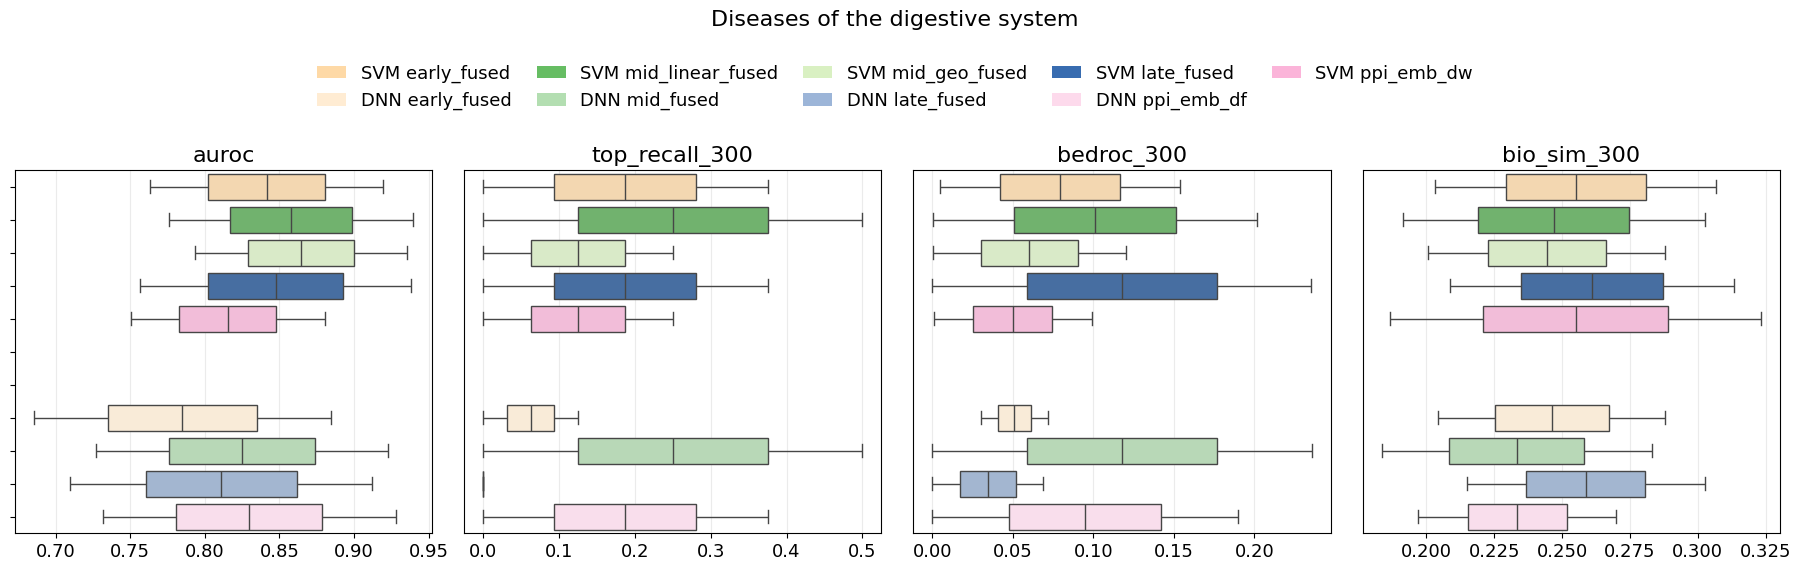

/tmp/ipykernel_3415367/553236826.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned, fontsize=13)


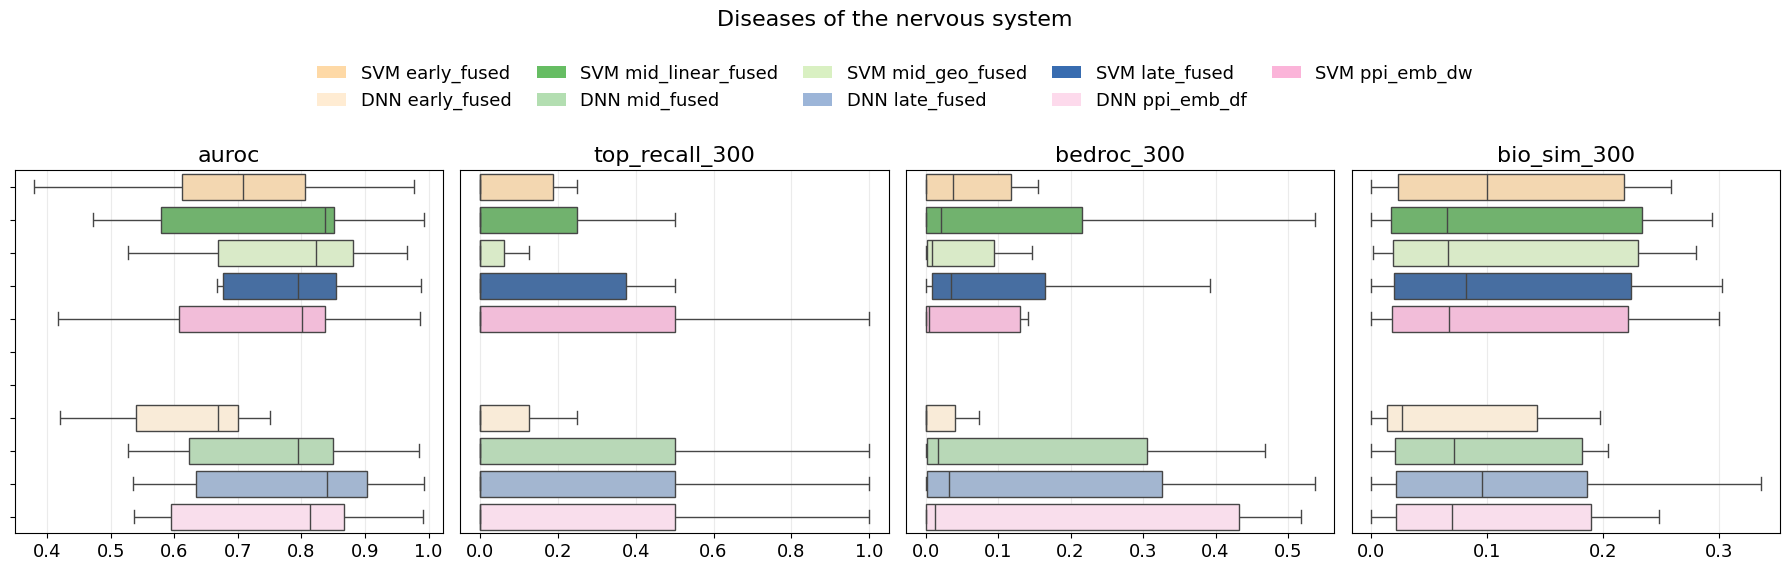

/tmp/ipykernel_3415367/553236826.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned, fontsize=13)


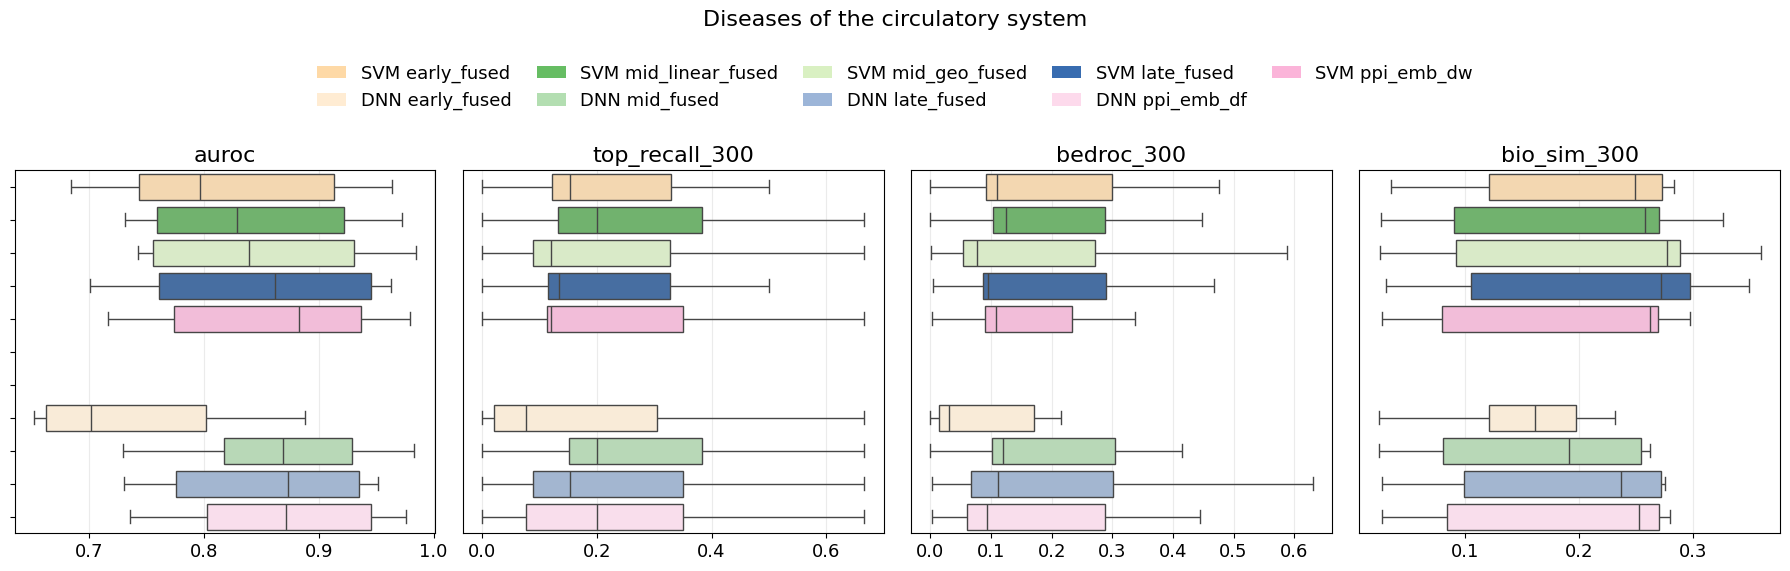

/tmp/ipykernel_3415367/553236826.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned, fontsize=13)


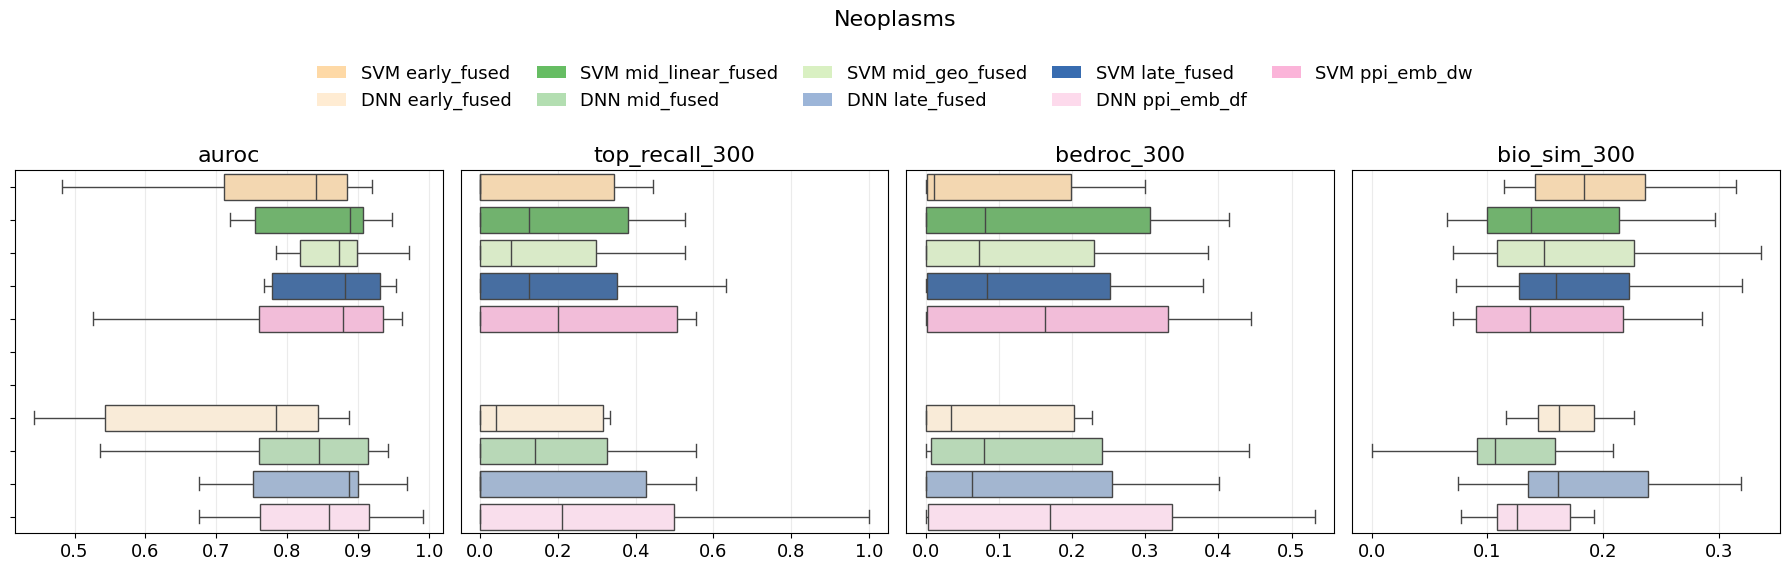

/tmp/ipykernel_3415367/553236826.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned, fontsize=13)


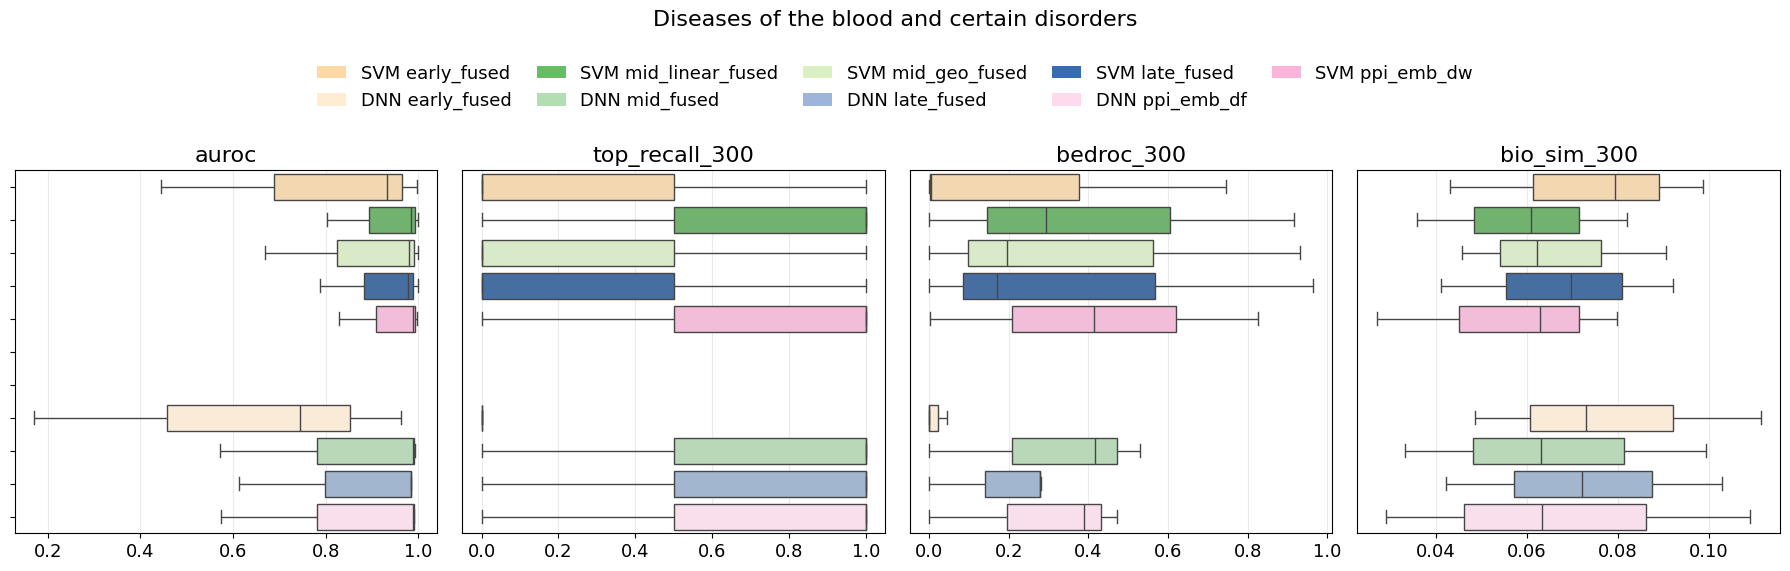

/tmp/ipykernel_3415367/553236826.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned, fontsize=13)


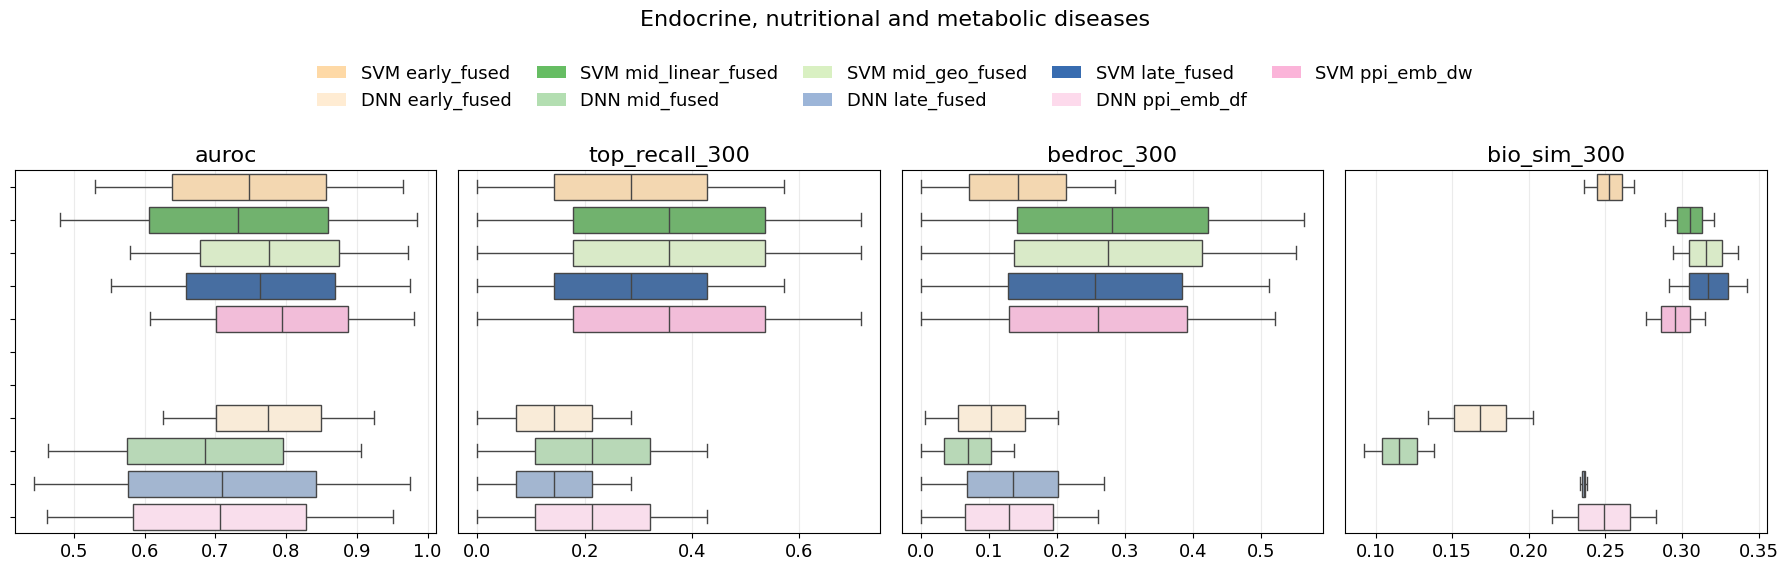

/tmp/ipykernel_3415367/553236826.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned, fontsize=13)


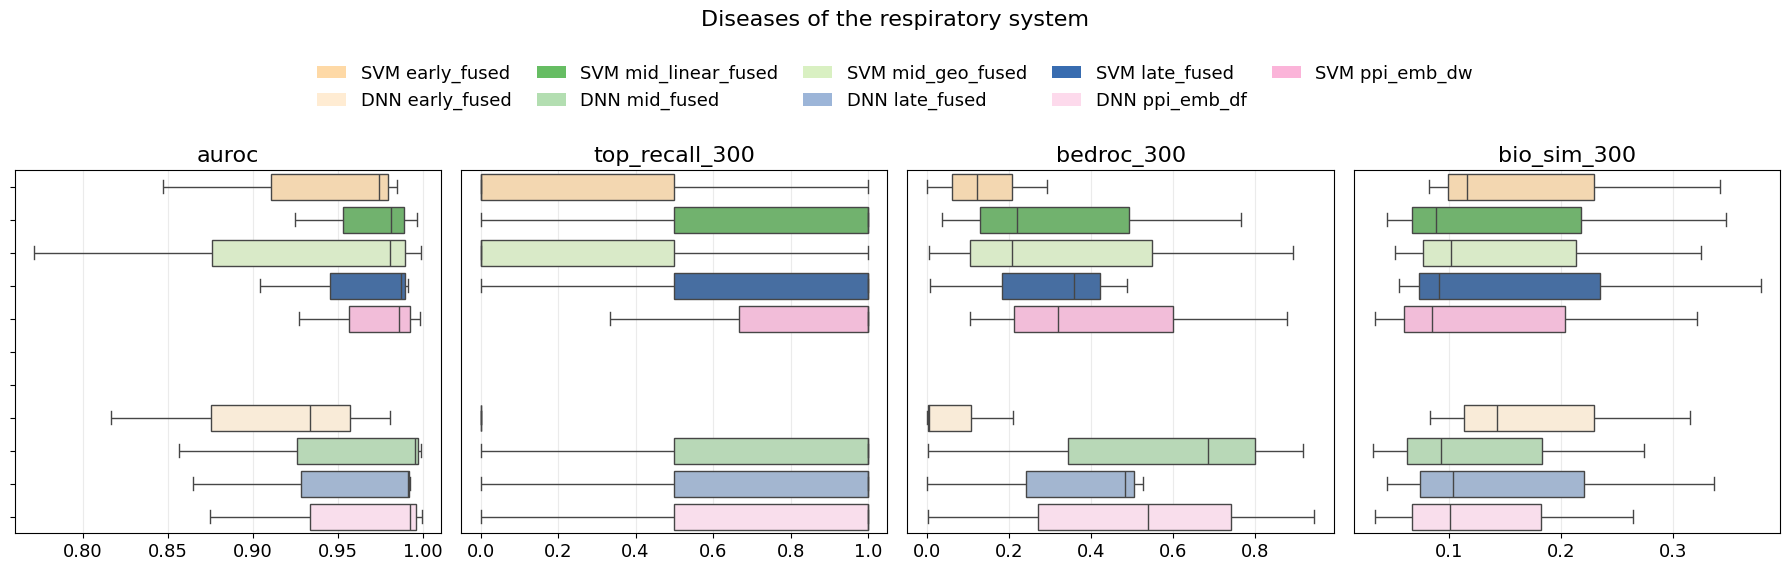

/tmp/ipykernel_3415367/553236826.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned, fontsize=13)


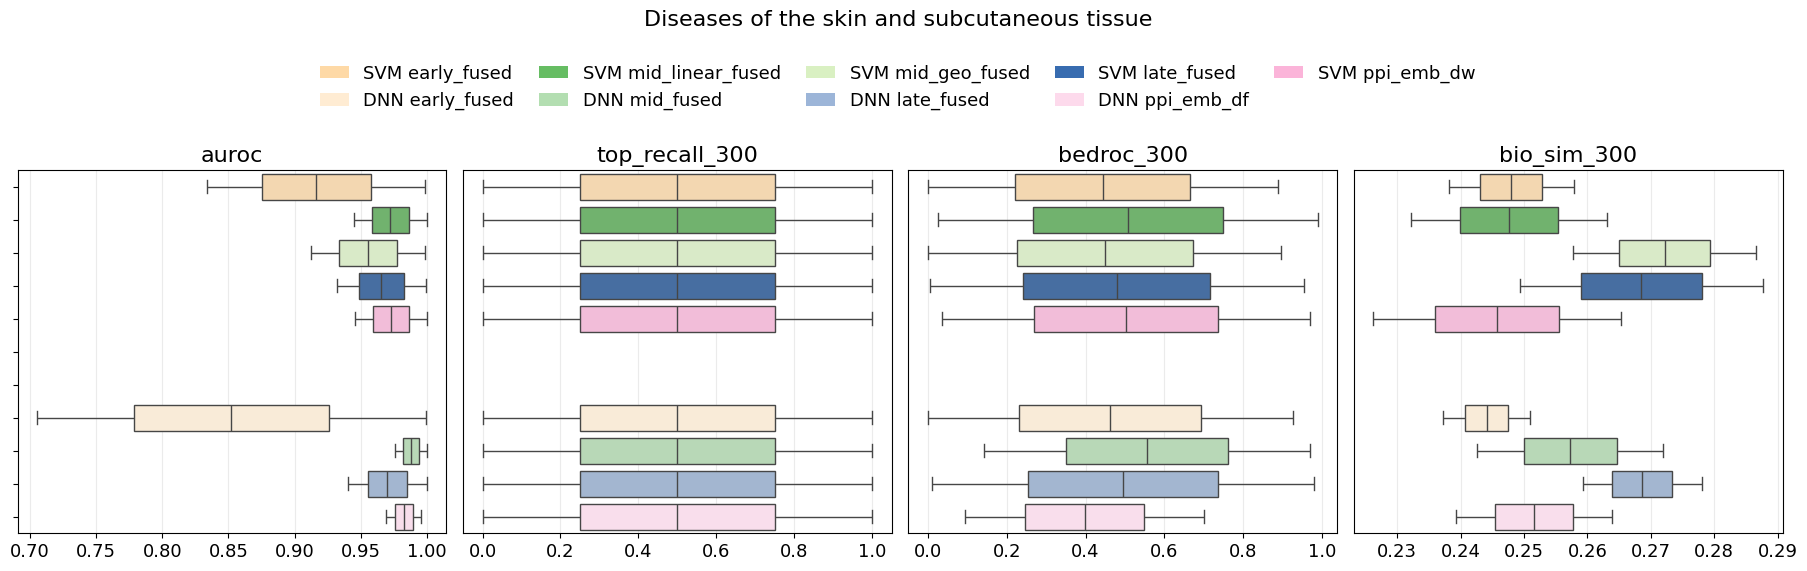

/tmp/ipykernel_3415367/553236826.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned, fontsize=13)


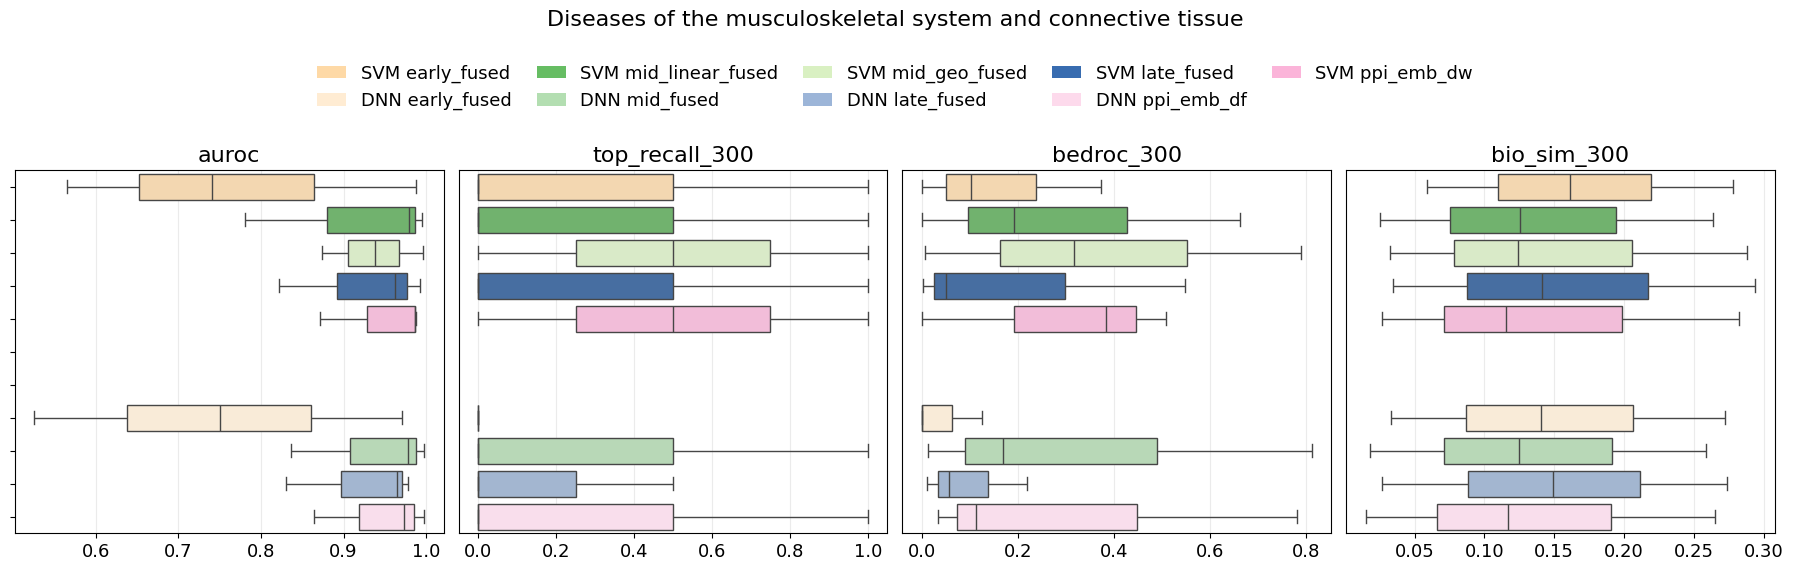

/tmp/ipykernel_3415367/553236826.py:230: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned, fontsize=13)


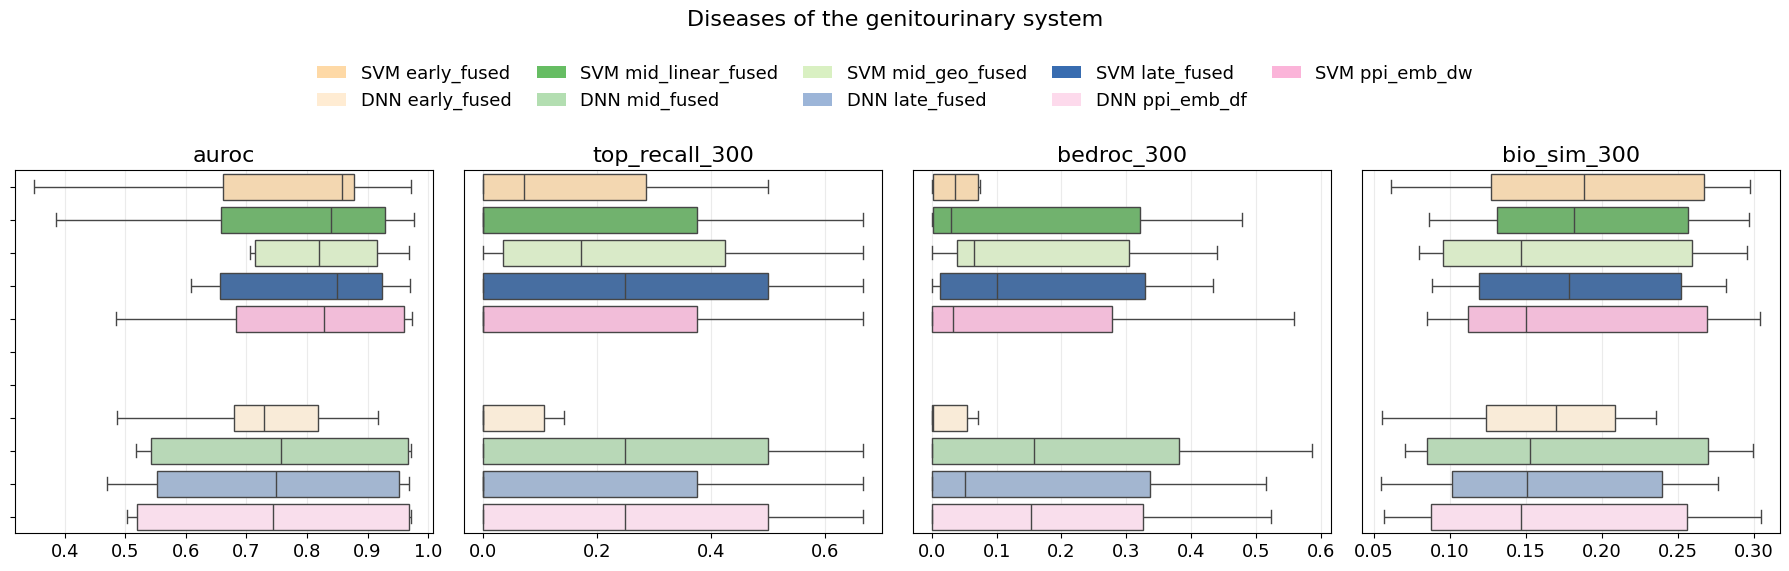

In [12]:
# selected_features = ['early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
#        'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']
selected_features = ['ppi_emb_dw','early_fused', 'late_fused', 'mid_fused','mid_linear_fused','mid_geo_fused']
subresults = merged_df[(merged_df['setting']=='df_gnn_occsvm_pred')&(merged_df['method'].isin(selected_features))]

selected_features2 = ['ppi_emb_df','early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
       'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']

subresults2 = merged_df[(merged_df['setting']=='2019_nn_all_pred')&(merged_df['method'].isin(selected_features2))]

for disease in disease_list:
    dissubresults = subresults[subresults['category']==disease]
    dissubresults2 = subresults2[subresults2['category']==disease]

    df_long = dissubresults.melt(id_vars=['disease','method'], value_vars=metrics, var_name='metric', value_name='value')
    df_long2 = dissubresults2.melt(id_vars=['disease','method'], value_vars=metrics, var_name='metric', value_name='value')

    plot_metric_boxplot(
        df_long, disease,
        ['early_fused', 'mid_linear_fused', 'mid_geo_fused', 'late_fused', 'ppi_emb_dw'],
        df_long2,
        ['early_fused', 'mid_fused', 'late_fused', 'ppi_emb_df'],
        metrics
    )

## ppi merge

/tmp/ipykernel_1320571/2751123420.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned)


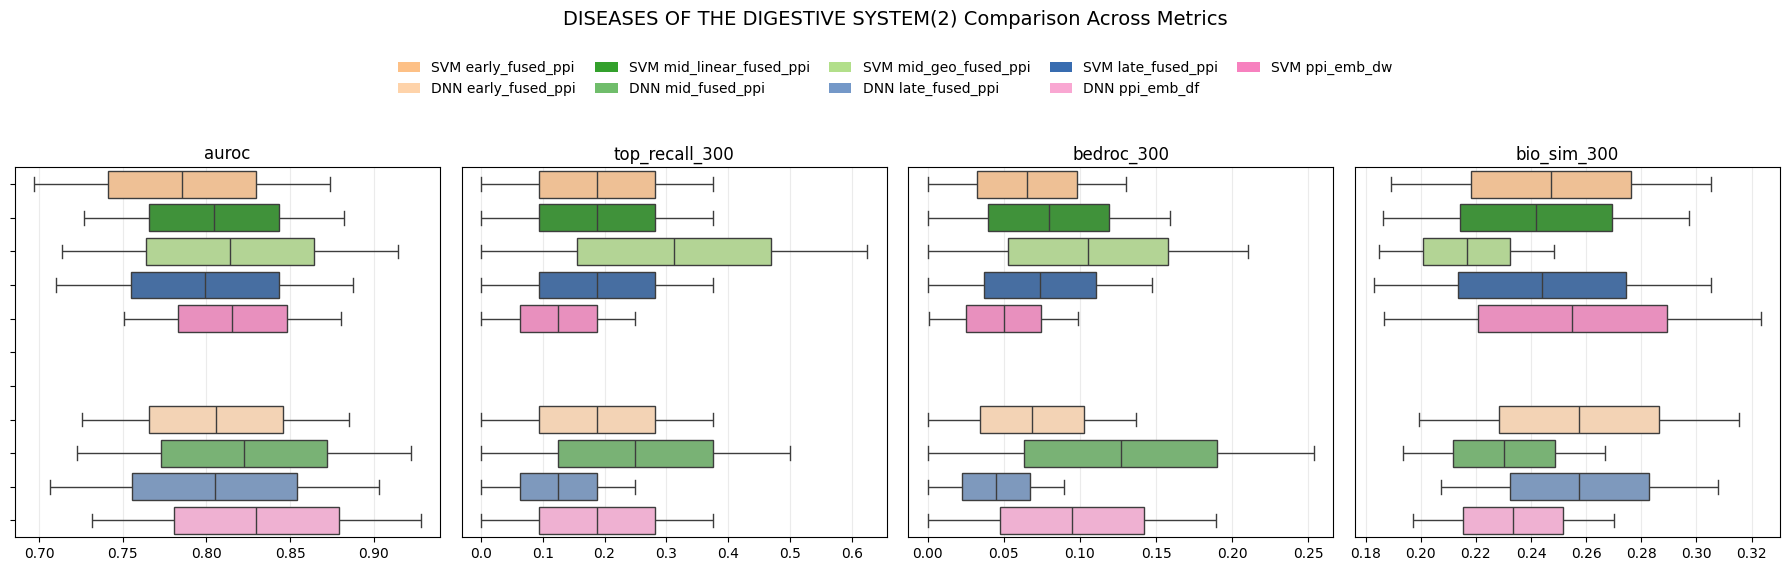

/tmp/ipykernel_1320571/2751123420.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned)


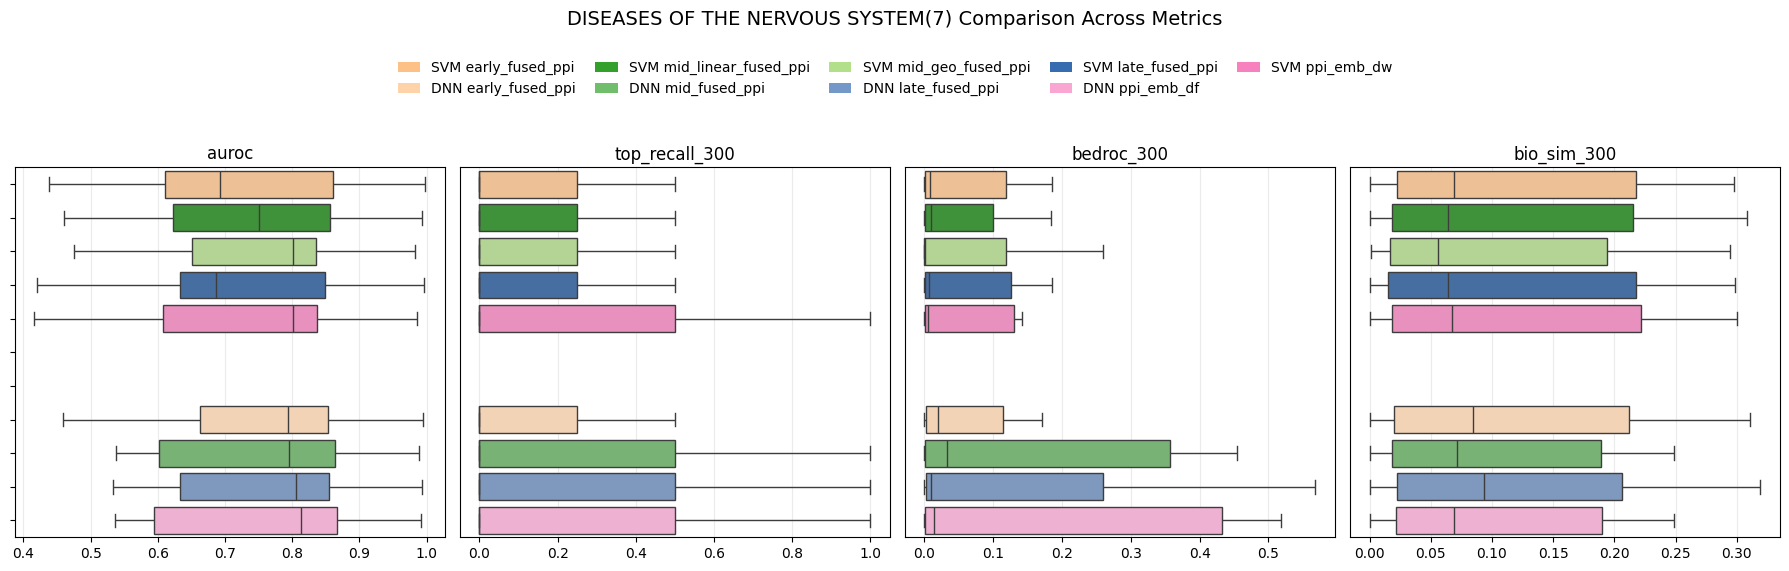

/tmp/ipykernel_1320571/2751123420.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned)


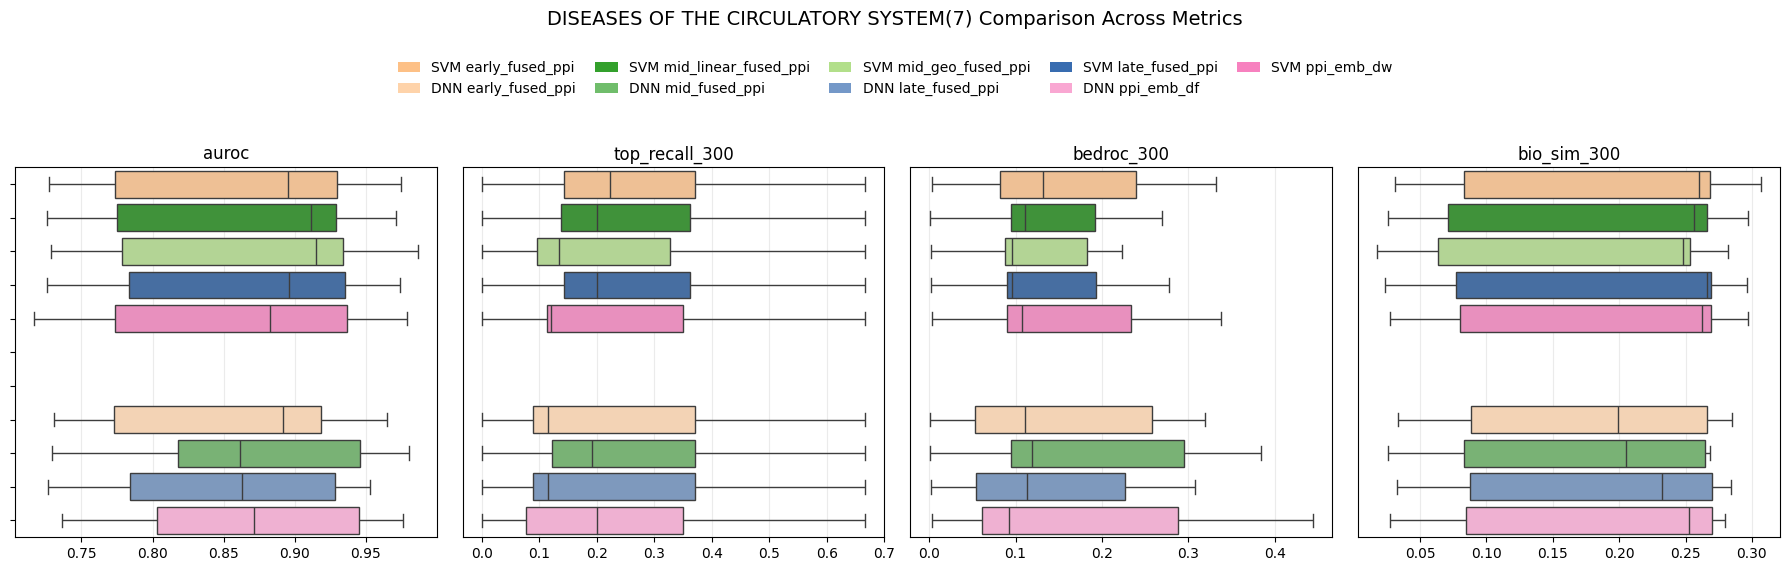

/tmp/ipykernel_1320571/2751123420.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned)


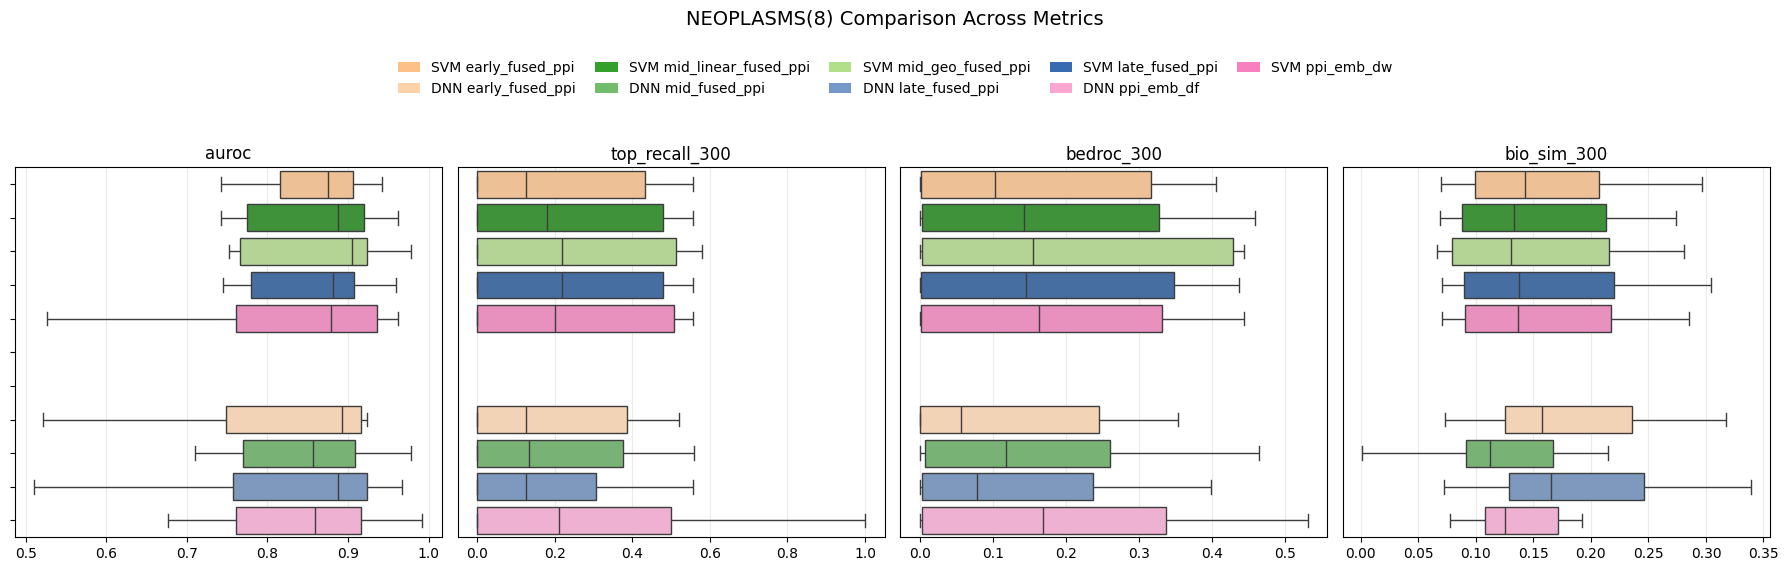

/tmp/ipykernel_1320571/2751123420.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned)


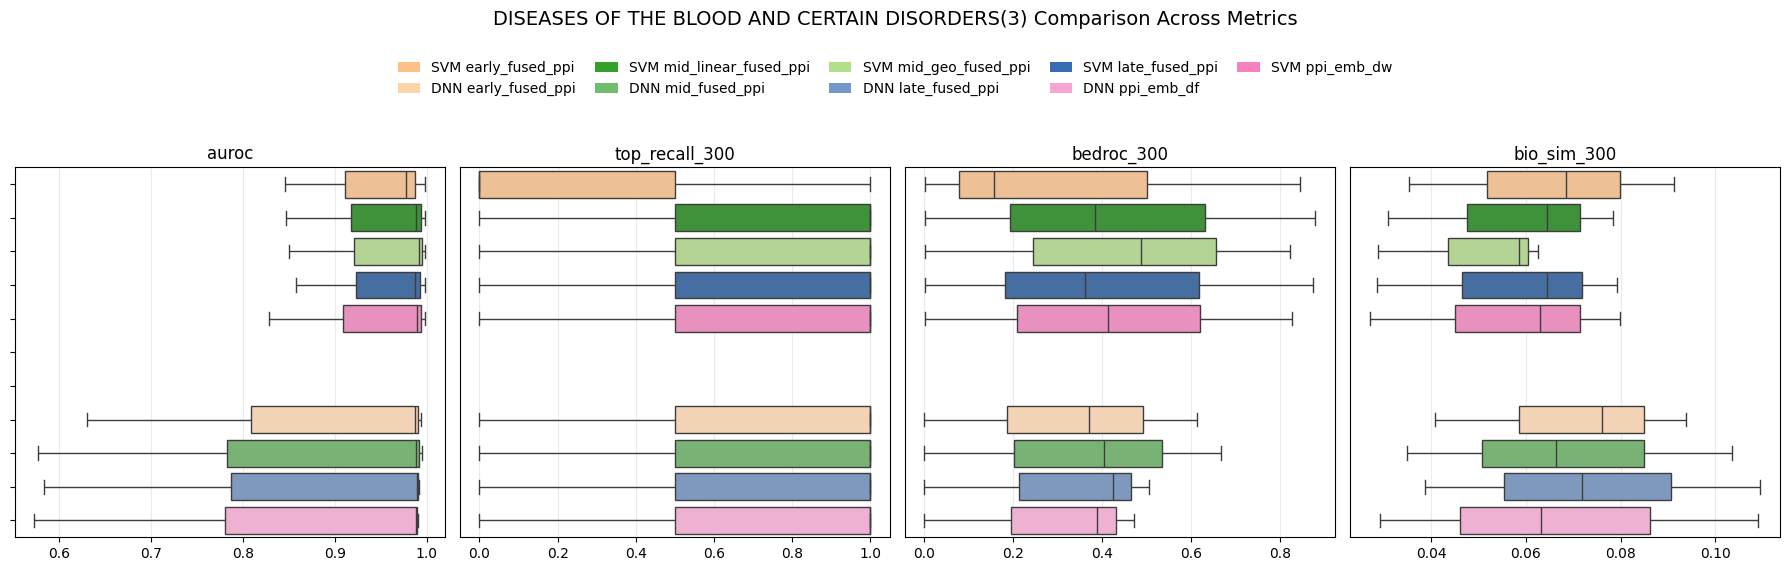

/tmp/ipykernel_1320571/2751123420.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned)


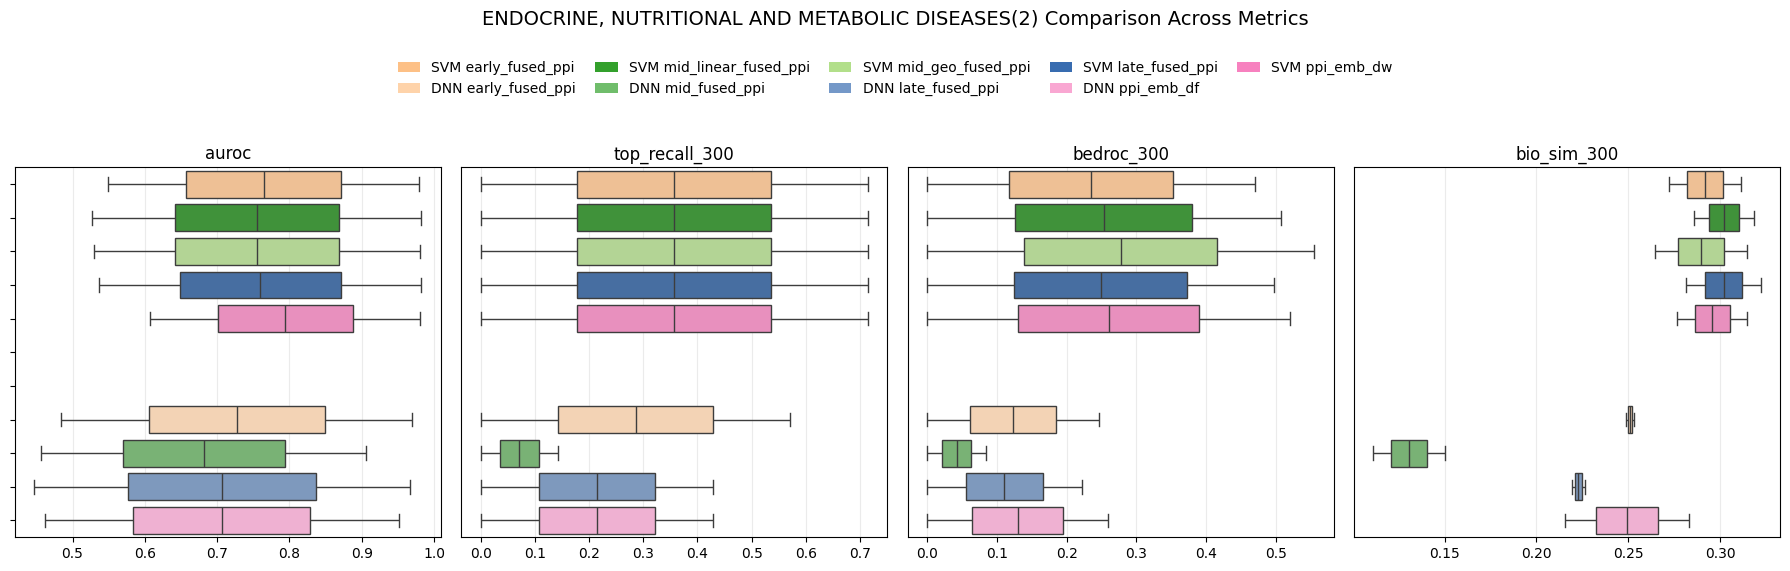

/tmp/ipykernel_1320571/2751123420.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned)


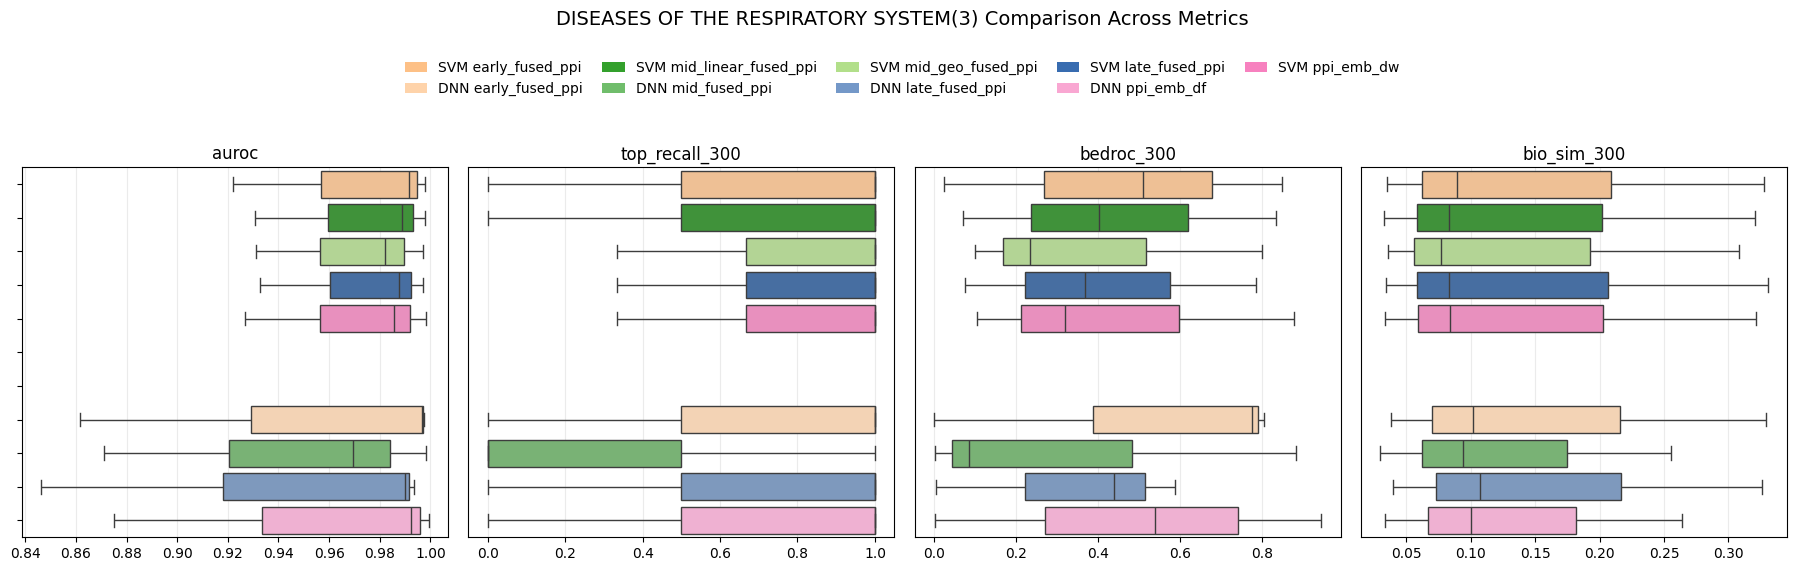

/tmp/ipykernel_1320571/2751123420.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned)


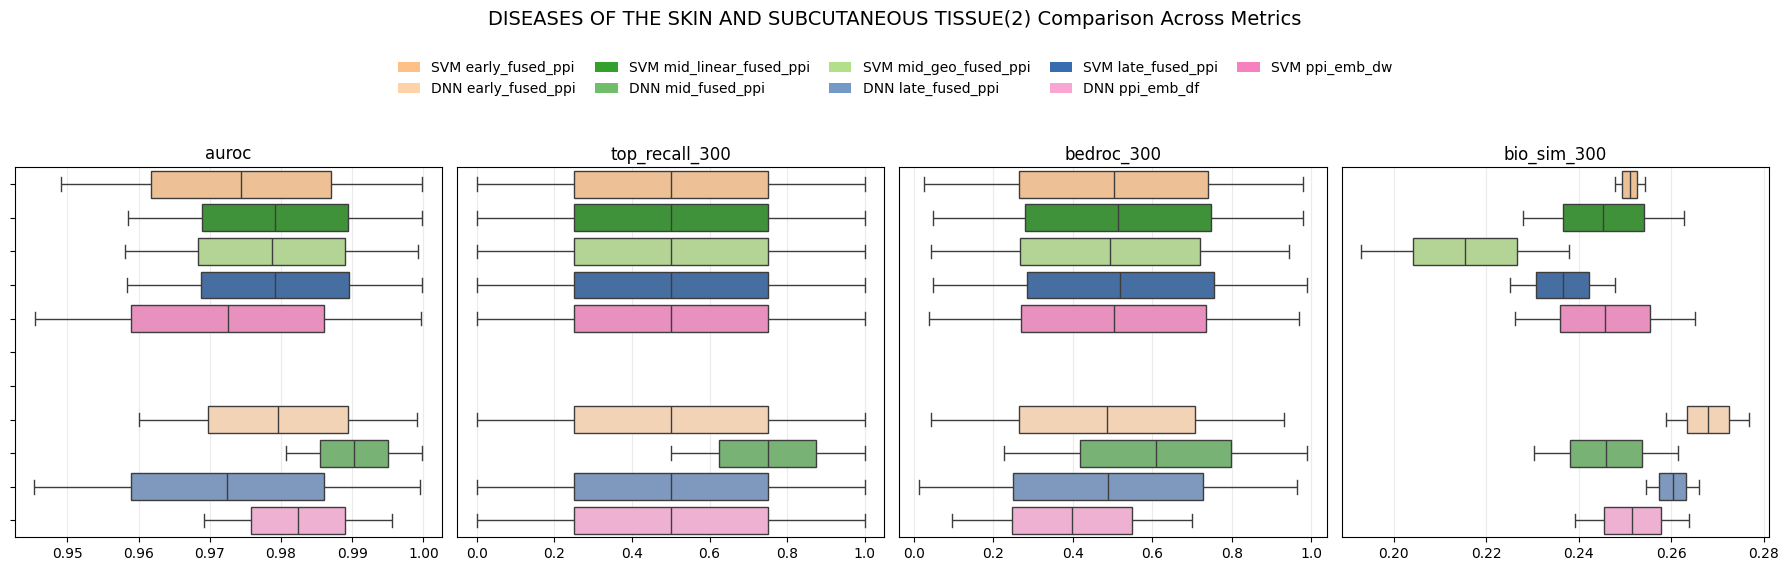

/tmp/ipykernel_1320571/2751123420.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned)


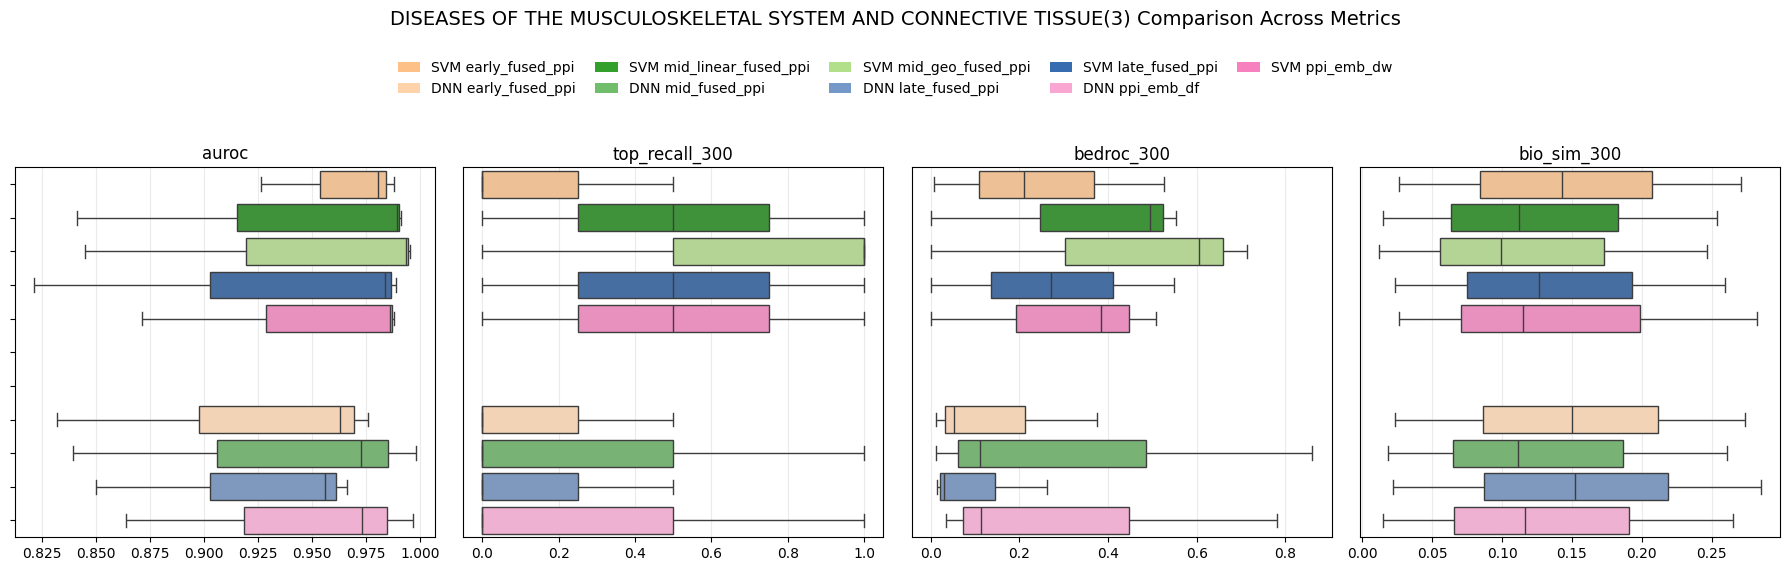

/tmp/ipykernel_1320571/2751123420.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cleaned)


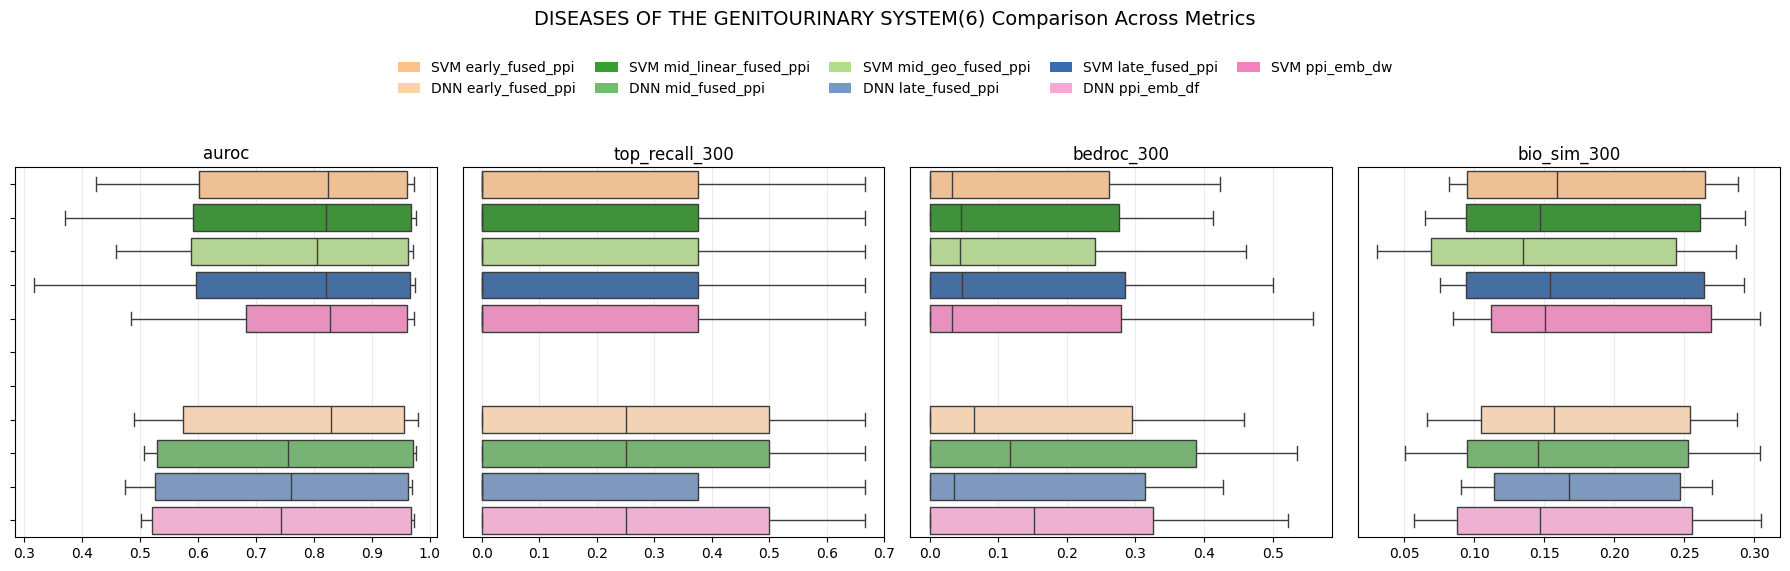

In [6]:
# selected_features = ['early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
#        'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']
selected_features = ['ppi_emb_dw','early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
       'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']
subresults = merged_df[(merged_df['setting']=='df_gnn_occsvm_pred')&(merged_df['method'].isin(selected_features))]

selected_features2 = ['ppi_emb_df','early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
       'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']

subresults2 = merged_df[(merged_df['setting']=='2019_nn_all_pred')&(merged_df['method'].isin(selected_features2))]

for disease in disease_list:
    dissubresults = subresults[subresults['category']==disease]
    dissubresults2 = subresults2[subresults2['category']==disease]

    df_long = dissubresults.melt(id_vars=['disease','method'], value_vars=metrics, var_name='metric', value_name='value')
    df_long2 = dissubresults2.melt(id_vars=['disease','method'], value_vars=metrics, var_name='metric', value_name='value')

    plot_metric_boxplot(
        df_long, disease,
        ['early_fused_ppi', 'mid_linear_fused_ppi', 'mid_geo_fused_ppi','late_fused_ppi', 'ppi_emb_dw'],
        df_long2,
        ['early_fused_ppi', 'mid_fused_ppi','late_fused_ppi', 'ppi_emb_df'],
        metrics
    )

In [50]:
disease_list = [
    'Diseases of the digestive system(2)',
    'Diseases of the musculoskeletal system and connective tissue(3)',
    'Diseases of the circulatory system(7)'
]

metrics = ['top_recall_300','top_recall_10%', 'auroc', 'bedroc_5', 'bedroc_10']

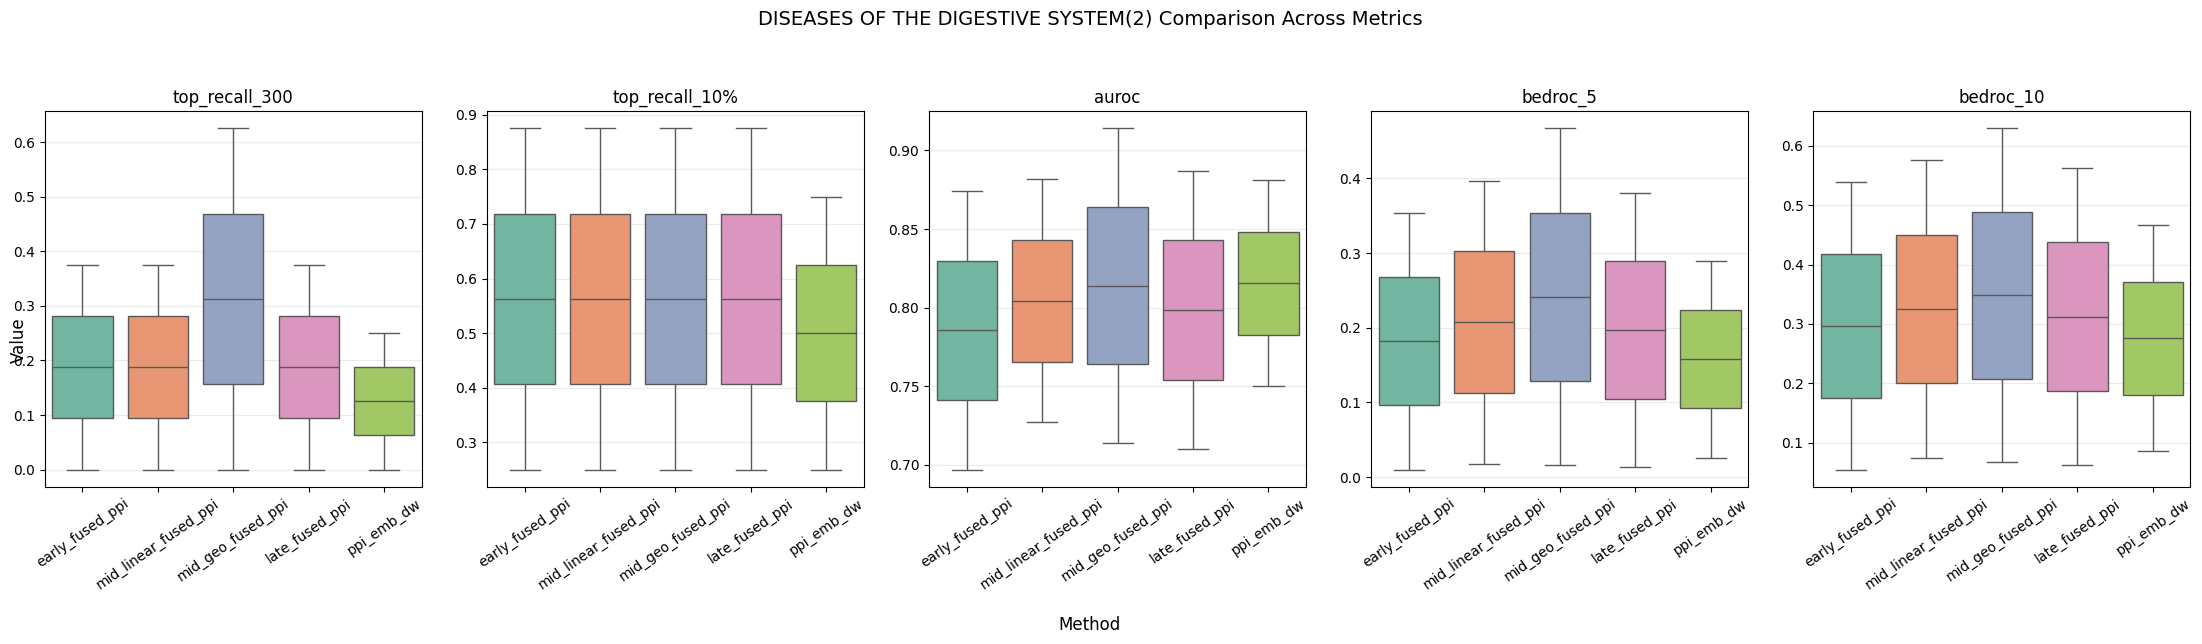

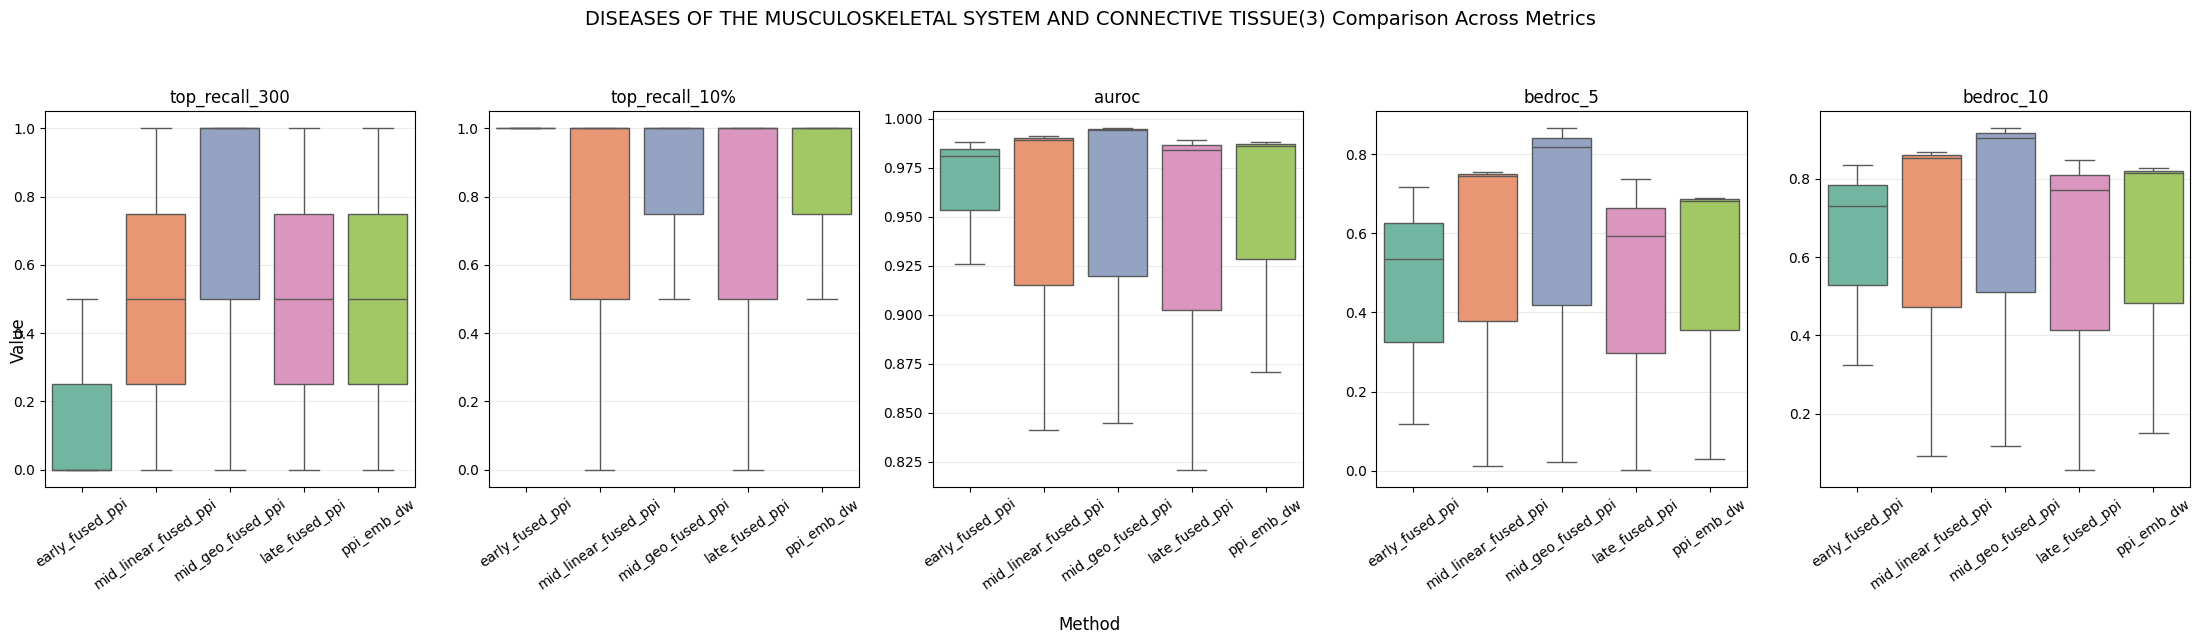

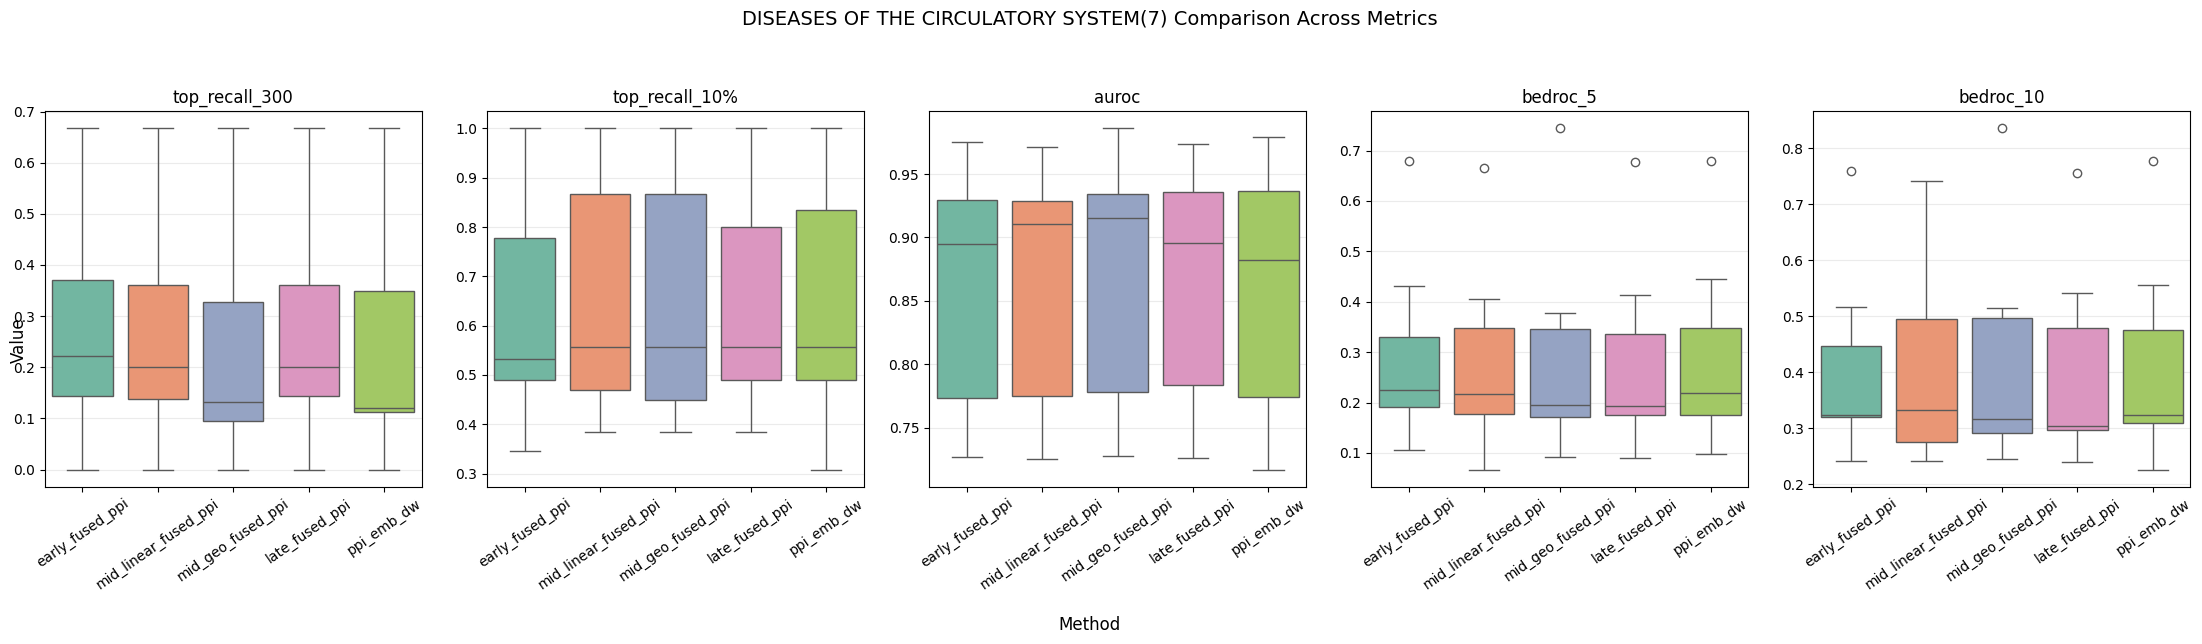

In [51]:
selected_features = ['ppi_emb_dw','early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
       'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']
subresults = merged_df[(merged_df['setting']=='df_gnn_occsvm_pred')&(merged_df['method'].isin(selected_features))]

for disease in disease_list:
    dissubresults = subresults[subresults['category']==disease]
    df_long = dissubresults.melt(id_vars=['disease','method'], value_vars=metrics, var_name='metric', value_name='value')
    plot_metric_boxplot(df_long, disease,['early_fused_ppi', 'mid_linear_fused_ppi', 'mid_geo_fused_ppi','late_fused_ppi','ppi_emb_dw'],metrics)

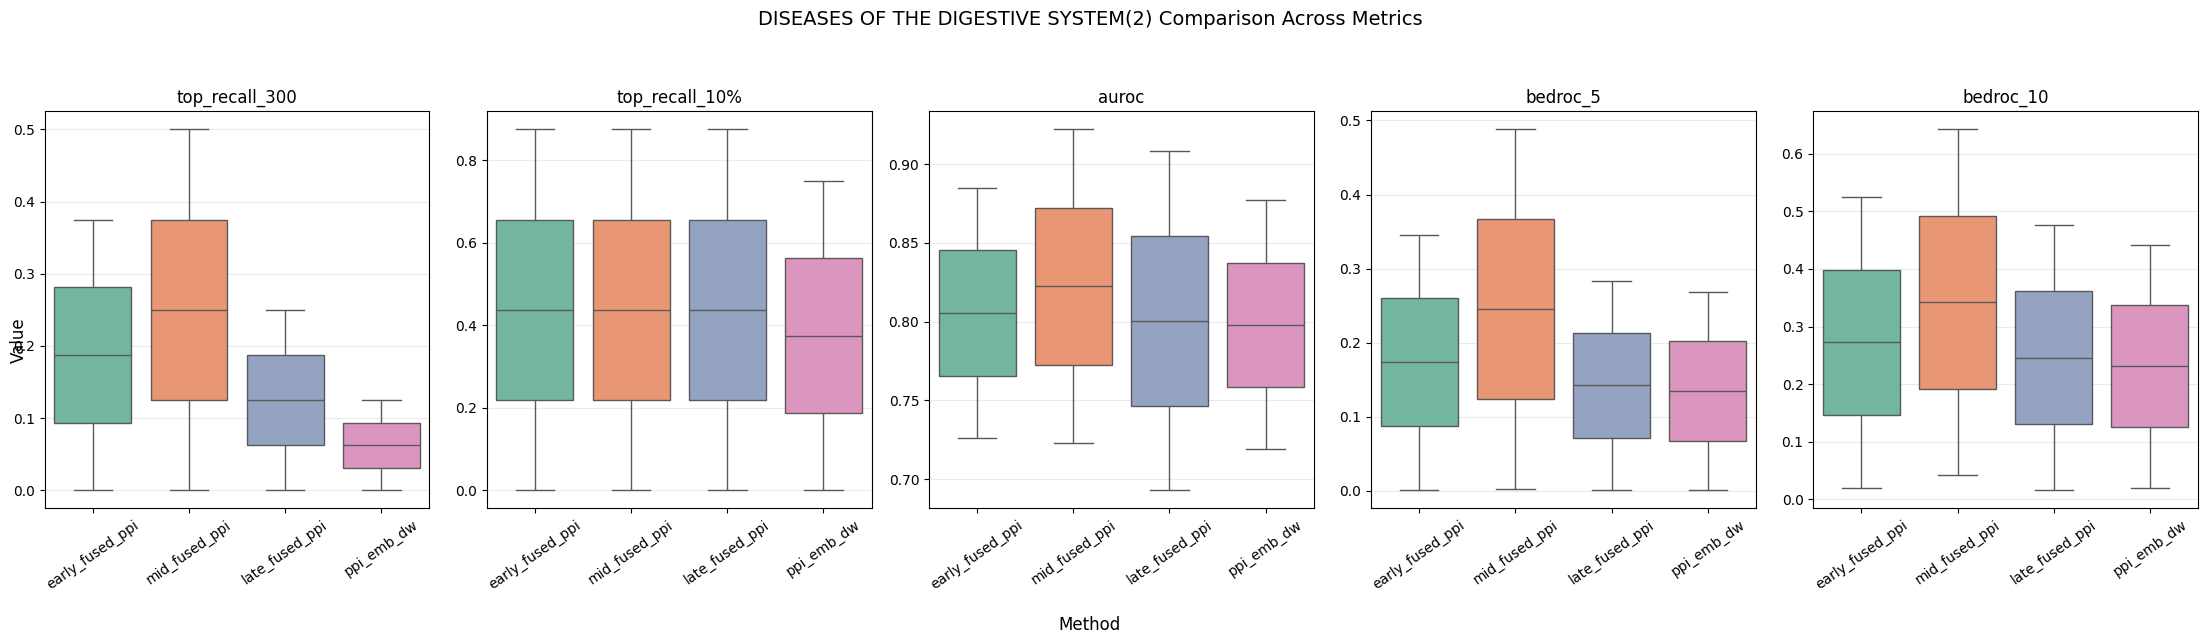

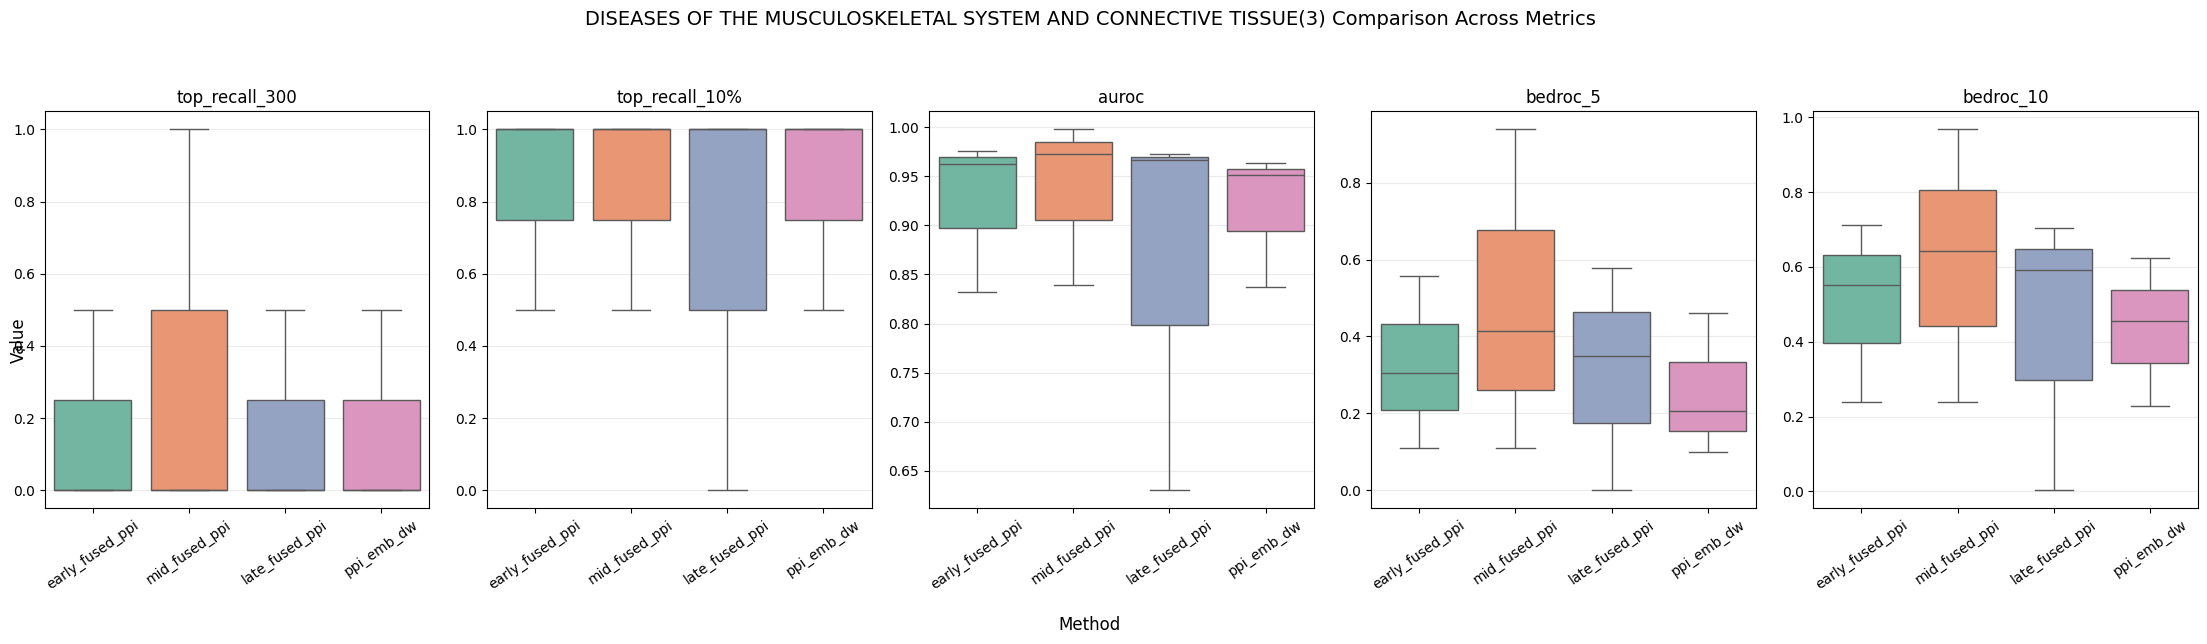

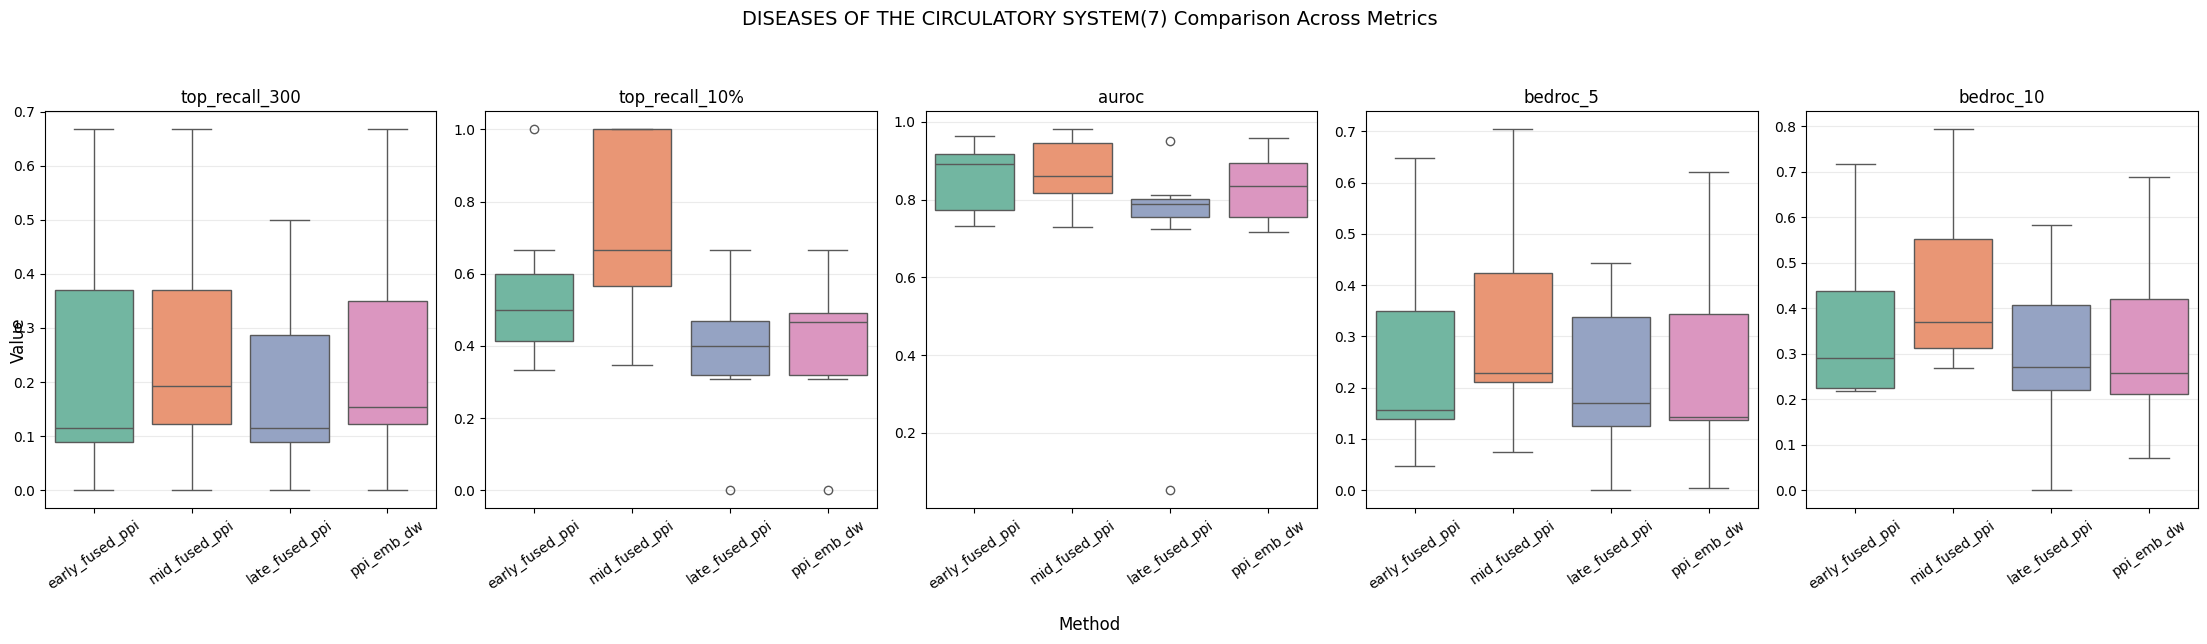

In [52]:
selected_features = ['ppi_emb_dw','early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
       'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']

subresults = merged_df[(merged_df['setting']=='2019_nn_all_pred')&(merged_df['method'].isin(selected_features))]

for disease in disease_list:
    dissubresults = subresults[subresults['category']==disease]
    df_long = dissubresults.melt(id_vars=['disease','method'], value_vars=metrics, var_name='metric', value_name='value')
    plot_metric_boxplot(df_long, disease,['early_fused_ppi', 'mid_fused_ppi','late_fused_ppi','ppi_emb_dw'],metrics)

## cancer related

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.colors import to_rgb

def _lighten_color(color, amount=0.30):
    r, g, b = to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

def plot_metric_boxplot_three_inputs(
    df_long, dis, legend_order_svm,
    df_long2, legend_order_dnn,
    df_long3, legend_order_mf,
    metrics_order,
    prefix1="SVM", prefix2="DNN", prefix3="MF",
    group_gap_label="__GAP__",
    gap_size_12=2,          # gap between SVM and DNN
    gap_size_23=2,          # gap between DNN and MF
    lighten_amount_dnn=0.30,
    lighten_amount_mf=0.10  # kept (not used since MF fixed color), so signature unchanged
):
    df1 = df_long.copy()
    df2 = df_long2.copy()
    df3 = df_long3.copy()

    # --- metric order ---
    for d in (df1, df2, df3):
        d["metric"] = pd.Categorical(d["metric"], categories=metrics_order, ordered=True)

    metrics = [m for m in metrics_order if (
        m in df1["metric"].unique() or m in df2["metric"].unique() or m in df3["metric"].unique()
    )]
    n = len(metrics)

    # --- base method names ---
    for d in (df1, df2, df3):
        d["method_base"] = d["method"].astype(str)

    # --- legend/y labels (renamed with prefix) ---
    df1["legend_label"] = prefix1 + " " + df1["method_base"]
    df2["legend_label"] = prefix2 + " " + df2["method_base"]
    df3["legend_label"] = prefix3 + " " + df3["method_base"]
    df1["method_disp"] = df1["legend_label"]
    df2["method_disp"] = df2["legend_label"]
    df3["method_disp"] = df3["legend_label"]

    # --- y-axis order: SVM + GAP + DNN + GAP + MF ---
    gap12 = [f"{group_gap_label}_12_{i}" for i in range(gap_size_12)]
    gap23 = [f"{group_gap_label}_23_{i}" for i in range(gap_size_23)]
    y_order = (
        [f"{prefix1} {m}" for m in legend_order_svm] +
        gap12 +
        [f"{prefix2} {m}" for m in legend_order_dnn] +
        gap23 +
        [f"{prefix3} {m}" for m in legend_order_mf]
    )

    # ---------- COLOR RULES (keep your current mapping) ----------
    BLUE   = "#386cb0"
    PINK   = "#f781bf"
    ORANGE = "#fdc086"
    GREEN  = "#b2df8a"
    GREEN2 = "#33a02c"
    MF_CLR = "#fb9a99"

    def base_color_for_method(m: str, mid_toggle: int):
        ml = str(m).lower()
        if "ppi" in ml:
            return PINK
        if "early" in ml:
            return ORANGE
        if "late" in ml:
            return BLUE
        if "mid" in ml:
            return GREEN2 if (mid_toggle % 2 == 0) else GREEN
        return "#808080"

    # unique base methods across all three orders (preserve order)
    all_base = []
    for m in (list(legend_order_svm) + list(legend_order_dnn)):
        if m not in all_base:
            all_base.append(m)

    mid_idx = 0
    base_method_color = {}
    for m in all_base:
        base_method_color[m] = base_color_for_method(m, mid_idx)
        if "mid" in str(m).lower():
            mid_idx += 1

    # palettes for prefixed labels
    svm_labels = [f"{prefix1} {m}" for m in legend_order_svm]
    dnn_labels = [f"{prefix2} {m}" for m in legend_order_dnn]
    mf_labels  = [f"{prefix3} {m}" for m in legend_order_mf]
    legend_order_labels = svm_labels + dnn_labels + mf_labels

    palette = {}
    for m in legend_order_svm:
        palette[f"{prefix1} {m}"] = base_method_color[m]

    for m in legend_order_dnn:
        palette[f"{prefix2} {m}"] = _lighten_color(base_method_color[m], amount=lighten_amount_dnn)

    # MF must NOT affect mid alternation; fixed color
    for m in legend_order_mf:
        palette[f"{prefix3} {m}"] = MF_CLR

    # --- figure ---
    fig, axes = plt.subplots(
        nrows=1,
        ncols=n,
        figsize=(4.5 * n, 4.9),
        sharey=True
    )
    if n == 1:
        axes = [axes]

    # dummy rows so gap categories always exist in the axis
    dummy_rows = pd.DataFrame({
        "method_disp": gap12 + gap23,
        "value": [0.0] * (len(gap12) + len(gap23)),
        # any valid hue value so seaborn is happy; doesn't affect colors mapping
        "legend_label": [svm_labels[0]] * (len(gap12) + len(gap23))
    })

    for i, metric in enumerate(metrics):
        ax = axes[i]
        sub1 = df1[df1["metric"] == metric][["method_disp", "value", "legend_label"]]
        sub2 = df2[df2["metric"] == metric][["method_disp", "value", "legend_label"]]
        sub3 = df3[df3["metric"] == metric][["method_disp", "value", "legend_label"]]

        if not sub1.empty:
            sns.boxplot(
                data=pd.concat([sub1, dummy_rows], ignore_index=True),
                y="method_disp", x="value",
                order=y_order,
                hue="legend_label", hue_order=legend_order_labels,
                palette=palette,
                dodge=False, legend=False, showfliers=False,
                ax=ax
            )
        if not sub2.empty:
            sns.boxplot(
                data=pd.concat([sub2, dummy_rows], ignore_index=True),
                y="method_disp", x="value",
                order=y_order,
                hue="legend_label", hue_order=legend_order_labels,
                palette=palette,
                dodge=False, legend=False, showfliers=False,
                ax=ax
            )
        if not sub3.empty:
            sns.boxplot(
                data=pd.concat([sub3, dummy_rows], ignore_index=True),
                y="method_disp", x="value",
                order=y_order,
                hue="legend_label", hue_order=legend_order_labels,
                palette=palette,
                dodge=False, legend=False, showfliers=False,
                ax=ax
            )

        ax.set_title(metric, fontsize=12)
        ax.set_xlabel("")
        ax.set_ylabel("")
        # --- x-axis range rule ---
        if str(metric).lower().startswith("bio"):
            # fit to data (SVM + DNN), ignore NaNs
            vals = pd.concat([sub1["value"], sub2["value"]], ignore_index=True).dropna()
            if len(vals) > 0:
                vmin = float(vals.min())
                vmax = float(vals.max())

                # small padding so boxes don't touch borders
                pad = 0.05 * (vmax - vmin) if vmax > vmin else (abs(vmax) * 0.05 if vmax != 0 else 0.05)
                ax.set_xlim(vmin - pad, vmax + pad)
            else:
                ax.set_xlim(0, 1)  # fallback
        else:
            ax.set_xlim(0, 1)
        ax.grid(axis="x", alpha=0.25)

        # y labels only on first subplot, hide gap labels there too
        if i != 0:
            ax.set_yticklabels([])
            ax.tick_params(axis="y", length=0)
        else:
            labels = [t.get_text() for t in ax.get_yticklabels()]
            labels = [("" if group_gap_label in lab else lab) for lab in labels]
            ax.set_yticklabels(labels)

    plt.subplots_adjust(wspace=0)

    # --- legend: 3 rows (SVM / DNN / MF) ---
    def make_handles(lbls):
        return [Patch(facecolor=palette[lbl], label=lbl) for lbl in lbls]

    row1 = make_handles(svm_labels)
    row2 = make_handles(dnn_labels)
    row3 = make_handles(mf_labels)

    ncol = max(len(row1), len(row2), len(row3))
    blank = Patch(facecolor=(0, 0, 0, 0), edgecolor=(0, 0, 0, 0), label="")

    row1 += [blank] * (ncol - len(row1))
    row2 += [blank] * (ncol - len(row2))
    row3 += [blank] * (ncol - len(row3))

    # Column-major interleaving to force row-wise appearance
    handles = []
    for c in range(ncol):
        handles.append(row1[c])  # SVM row
        handles.append(row2[c])  # DNN row
        handles.append(row3[c])  # MF row

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=ncol,
        frameon=False,
        bbox_to_anchor=(0.5, 1.14),
        handlelength=1.6,
        columnspacing=1.4
    )

    fig.suptitle(f"{str(dis).upper()} Comparison Across Metrics", fontsize=14, y=1.20)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2956590/1406069261.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults3['method'] = 'ppi_emb_n2v'
/tmp/ipykernel_2956590/2713665849.py:191: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


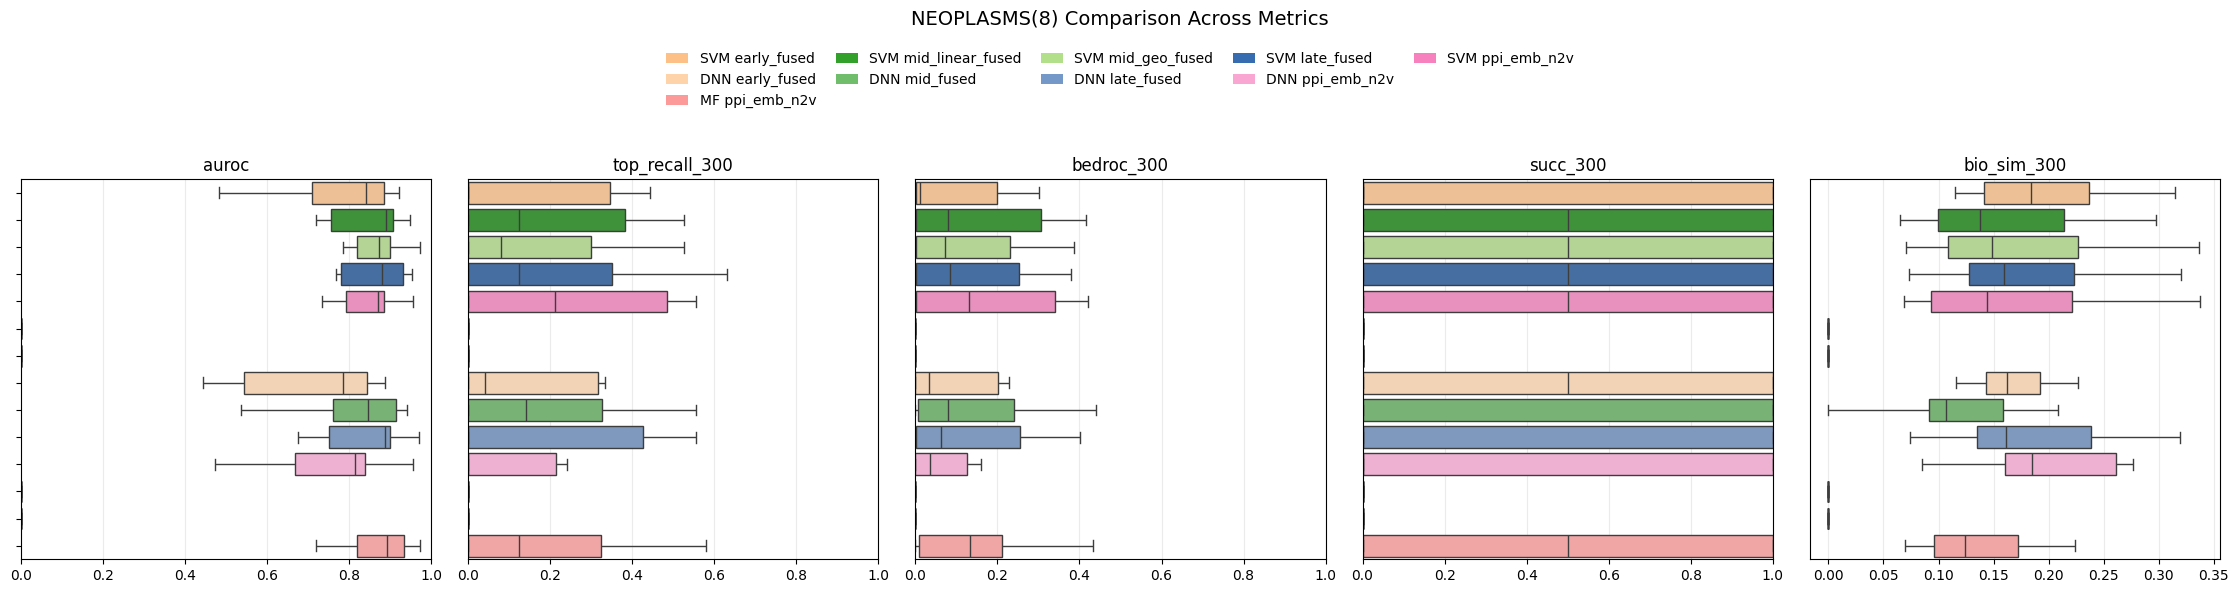

In [6]:
subresults3 = merged_df[merged_df['setting']=='2019_mf_bag_2_pred']
subresults3['method'] = 'ppi_emb_n2v'

disease = 'Neoplasms(8)'

selected_features = ['ppi_emb_n2v','early_fused', 'late_fused', 'mid_fused','mid_linear_fused','mid_geo_fused']
subresults = merged_df[(merged_df['setting']=='df_gnn_occsvm_pred')&(merged_df['method'].isin(selected_features))]

selected_features2 = ['ppi_emb_n2v','early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
       'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']

subresults2 = merged_df[(merged_df['setting']=='2019_nn_all_pred')&(merged_df['method'].isin(selected_features2))]

dissubresults = subresults[subresults['category']==disease]
dissubresults2 = subresults2[subresults2['category']==disease]

df_long = dissubresults.melt(id_vars=['disease','method'], value_vars=metrics, var_name='metric', value_name='value')
df_long2 = dissubresults2.melt(id_vars=['disease','method'], value_vars=metrics, var_name='metric', value_name='value')

dissubresults3 = subresults3[subresults3['category']==disease]
df_long3 = dissubresults3.melt(id_vars=['disease','method'], value_vars=metrics, var_name='metric', value_name='value')

plot_metric_boxplot_three_inputs(
    df_long, disease,
    ['early_fused', 'mid_linear_fused', 'mid_geo_fused', 'late_fused', 'ppi_emb_n2v'],
    df_long2,
    ['early_fused', 'mid_fused', 'late_fused', 'ppi_emb_n2v'],
    df_long3,
    ['ppi_emb_n2v'],
    metrics
)